In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. FUNÇÃO DE CARREGAMENTO E LIMPEZA (Já validada) ---
def load_and_clean_data(file_path, symbol):
    """
    Carrega os CSVs formatados em português (DD.MM.YYYY, decimal ',', milhar '.')
    """
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'], # Carrega apenas colunas necessárias
            parse_dates=['Data'],
            dayfirst=True # Indica que o formato é DD/MM/YYYY
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index().duplicated(keep='last')] # Remove datas duplicadas
        return data
    except Exception as e:
        # print(f"Erro ao carregar {file_path}: {e}") # Descomente para debug
        return None

# --- 2. CARREGAMENTO E ALINHAMENTO (MÉTODO 'INNER') ---
print("Carregando e alinhando dados (Método 'INNER')...")
files = {
    'btc': 'BTC.csv',
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}
image_files = [] # Lista para armazenar os nomes dos arquivos de imagem

df_list = []
for symbol, file_path in files.items():
    # Verifica se o arquivo existe antes de tentar carregar
    if not os.path.exists(file_path):
        print(f"AVISO: Arquivo {file_path} não encontrado. Pulando este ativo.")
        continue
    df = load_and_clean_data(file_path, symbol)
    if df is not None:
        df_list.append(df)

if len(df_list) < 3:
    print("ERRO: Não foi possível carregar todos os 3 arquivos. Análise cancelada.")
else:
    # 'inner': Mantém apenas as datas que existem em TODOS os 3 arquivos.
    data_aligned_inner = pd.concat(df_list, axis=1, join='inner')
    data_aligned_inner.sort_index(inplace=True)

    # Garante que todos os dados são numéricos e remove NaNs
    for col in data_aligned_inner.columns:
        data_aligned_inner[col] = pd.to_numeric(data_aligned_inner[col], errors='coerce')
    data_aligned_inner.dropna(inplace=True)

    print(f"Dados prontos. {len(data_aligned_inner)} dias de negociação em comum encontrados.")

    # --- 3. CÁLCULO DOS RETORNOS DIÁRIOS (FEITO UMA SÓ VEZ) ---
    print("\nCalculando retornos diários (base 'INNER')...")
    returns_inner = data_aligned_inner.pct_change().dropna()
    returns_inner.columns = [f'{col}_ret' for col in returns_inner.columns]
    corr_total = returns_inner.corr()

    # --- 4. LISTA DE RECORTES PARA ANALISAR ---
    # Adicionando os recortes de 2020 e 2021 conforme solicitado
    split_dates = ['2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01']

    print("\n--- MATRIZ (PERÍODO TOTAL) ---")
    print(corr_total)

    # Loop para criar cada análise de recorte
    for date_str in split_dates:
        year = date_str.split('-')[0]
        print(f"\n\n--- ANÁLISE: Recorte em {date_str} ---")
        
        # Separa os dataframes de retorno
        returns_pre = returns_inner[returns_inner.index < date_str]
        returns_post = returns_inner[returns_inner.index >= date_str]
        
        # Calcula as matrizes de correlação
        corr_pre = returns_pre.corr()
        corr_post = returns_post.corr()
        
        # --- Apresentação dos Resultados ---
        print(f"\n--- MATRIZ (ANTES DE {date_str}) ---")
        print(corr_pre)
        print(f"\n--- MATRIZ ({date_str} EM DIANTE) ---")
        print(corr_post)
        
        # --- Plotagem ---
        fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
        
        # Plot 1: Período Total
        sns.heatmap(corr_total, ax=axes[0], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[0].set_title(f'Período Total\n(n={len(returns_inner)})')
        
        # Plot 2: Antes do Recorte
        sns.heatmap(corr_pre, ax=axes[1], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[1].set_title(f'Antes de {date_str}\n(n={len(returns_pre)})')
        
        # Plot 3: Depois do Recorte
        sns.heatmap(corr_post, ax=axes[2], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[2].set_title(f'{date_str} em Diante\n(n={len(returns_post)})')
        
        plt.suptitle(f'Comparação Temporal das Matrizes de Correlação (Recorte em {year})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta layout
        
        # Salva o gráfico com um nome de arquivo único
        filename = f'correlation_comparison_{year}.png'
        plt.savefig(filename)
        image_files.append(filename)
        print(f"\nGráfico '{filename}' salvo.")

    print(f"\n\n--- Processo Concluído ---")
    print(f"Gráficos gerados: {', '.join(image_files)}")

Carregando e alinhando dados (Método 'INNER')...
ERRO: Não foi possível carregar todos os 3 arquivos. Análise cancelada.


Carregando e alinhando dados (Método 'INNER')...
Dados prontos. 3525 dias de negociação em comum encontrados.

Calculando retornos diários (base 'INNER')...

--- MATRIZ (PERÍODO TOTAL) ---
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.132264 -0.153569
xau_ret  0.132264  1.000000 -0.107796
ng_ret  -0.153569 -0.107796  1.000000


--- ANÁLISE: Recorte em 2018-01-01 ---

--- MATRIZ (ANTES DE 2018-01-01) ---
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000 -0.015114 -0.042510
xau_ret -0.015114  1.000000  0.028364
ng_ret  -0.042510  0.028364  1.000000

--- MATRIZ (2018-01-01 EM DIANTE) ---
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.433841 -0.338569
xau_ret  0.433841  1.000000 -0.203933
ng_ret  -0.338569 -0.203933  1.000000

Gráfico 'correlation_comparison_2018.png' salvo.


--- ANÁLISE: Recorte em 2019-01-01 ---

--- MATRIZ (ANTES DE 2019-01-01) ---
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000 -0.015714 -0.042995
xau_ret -0.015714  1.000000  0.0

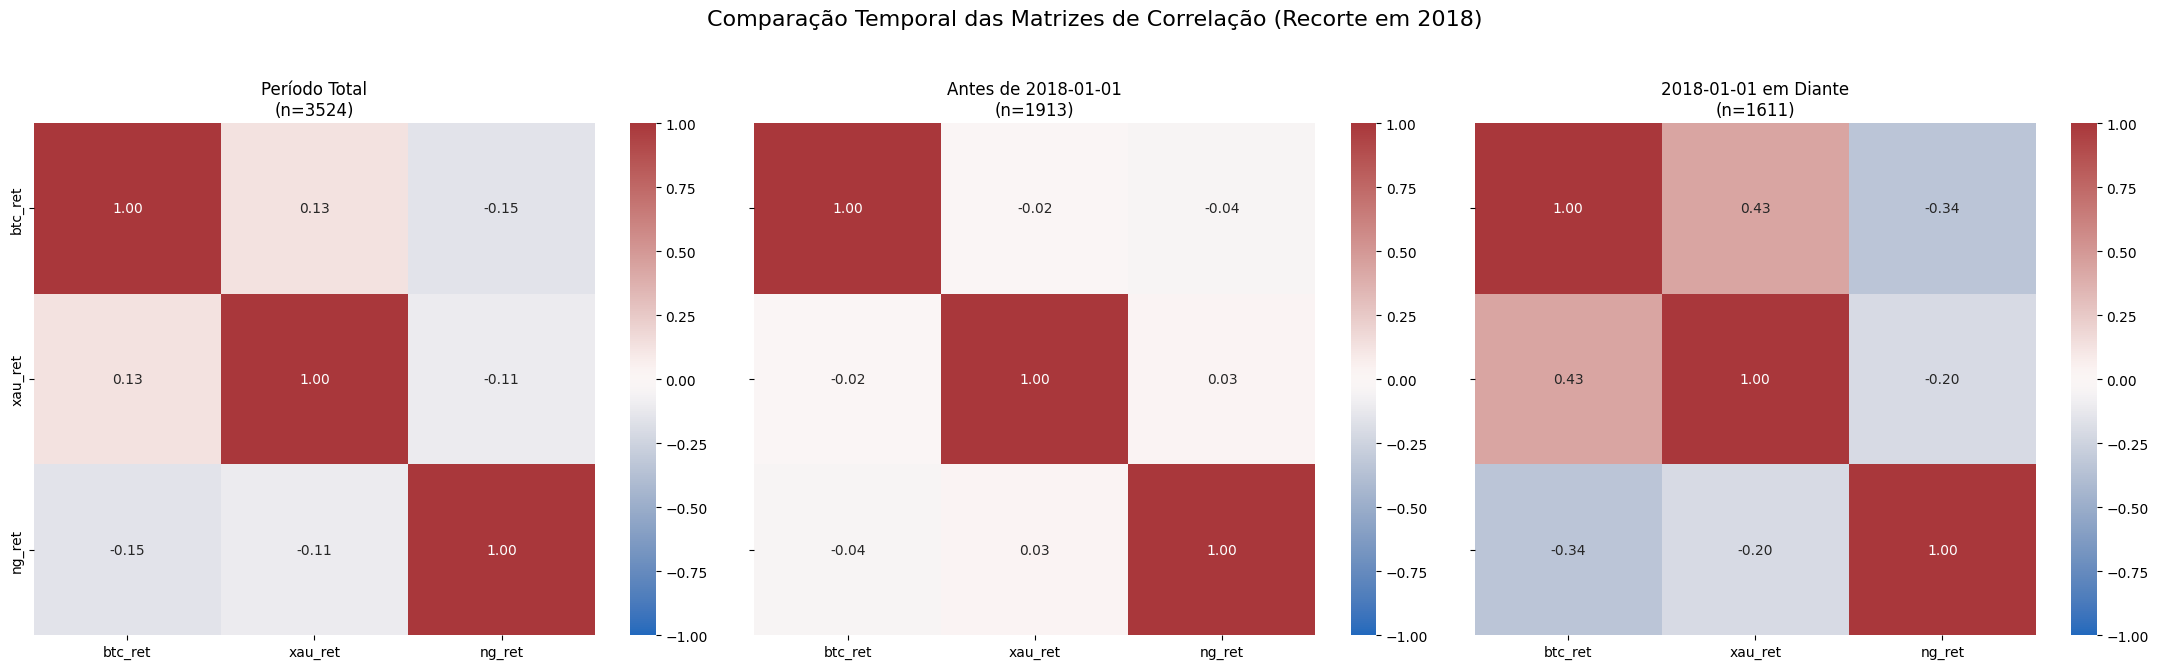

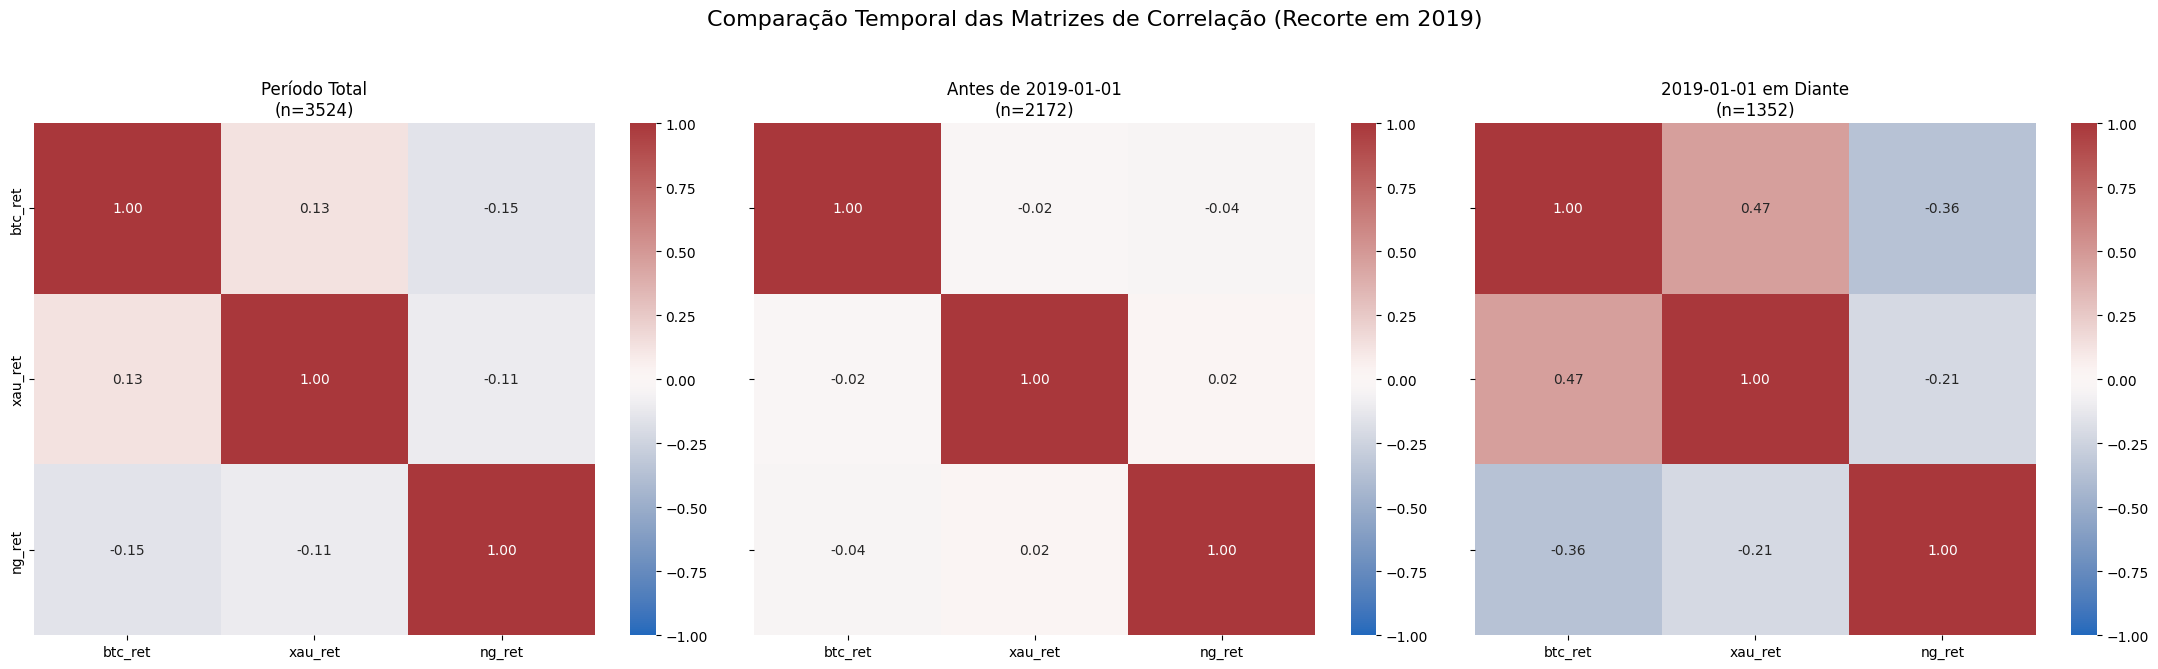

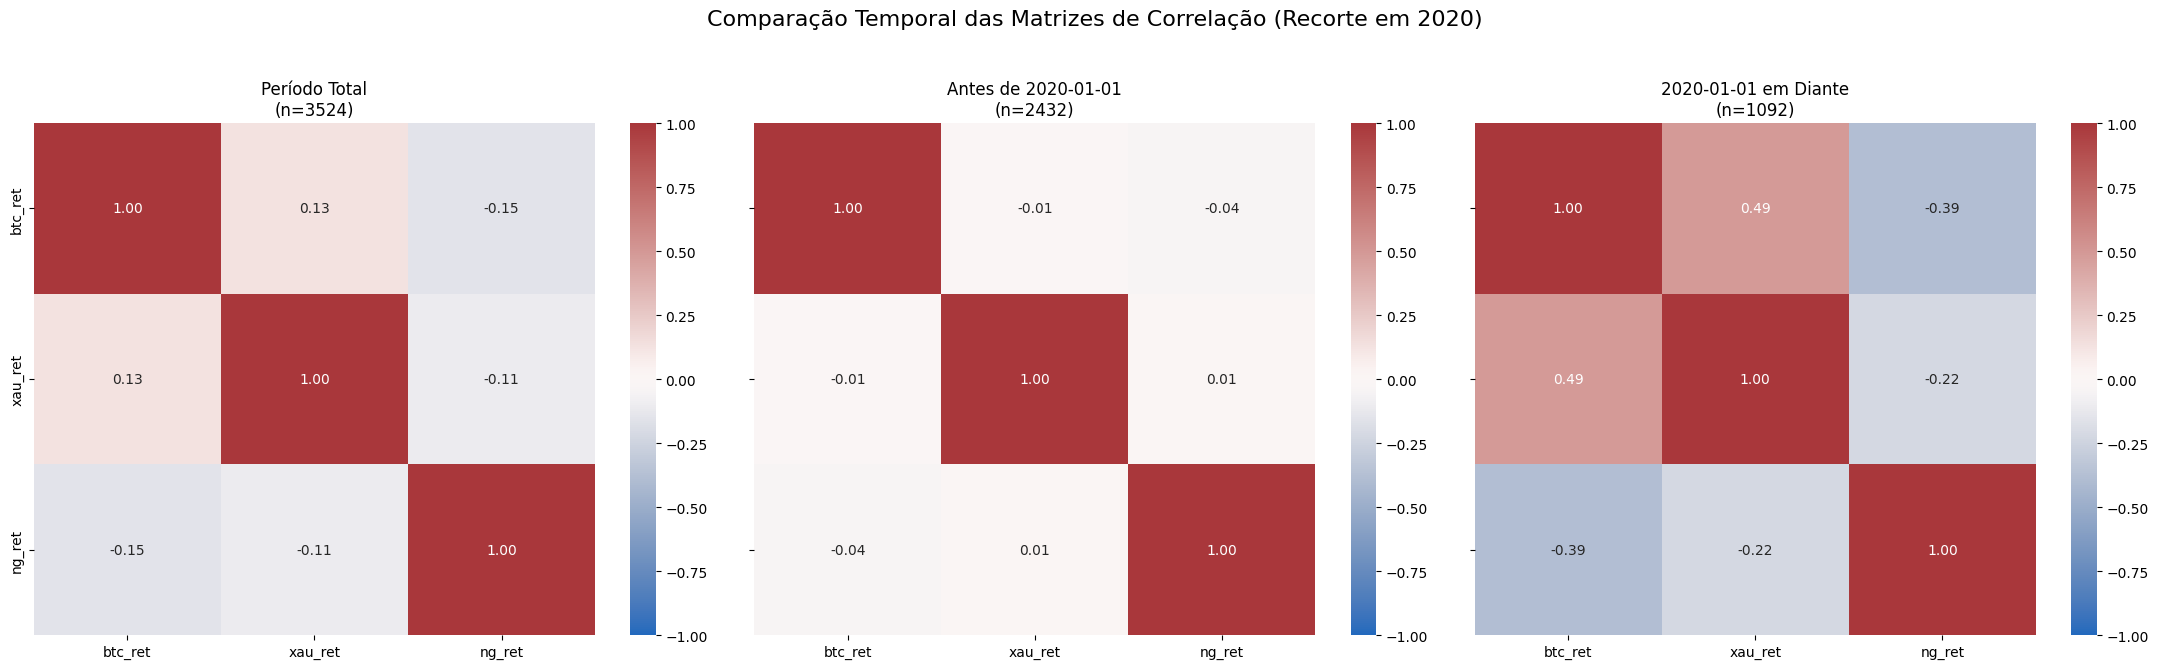

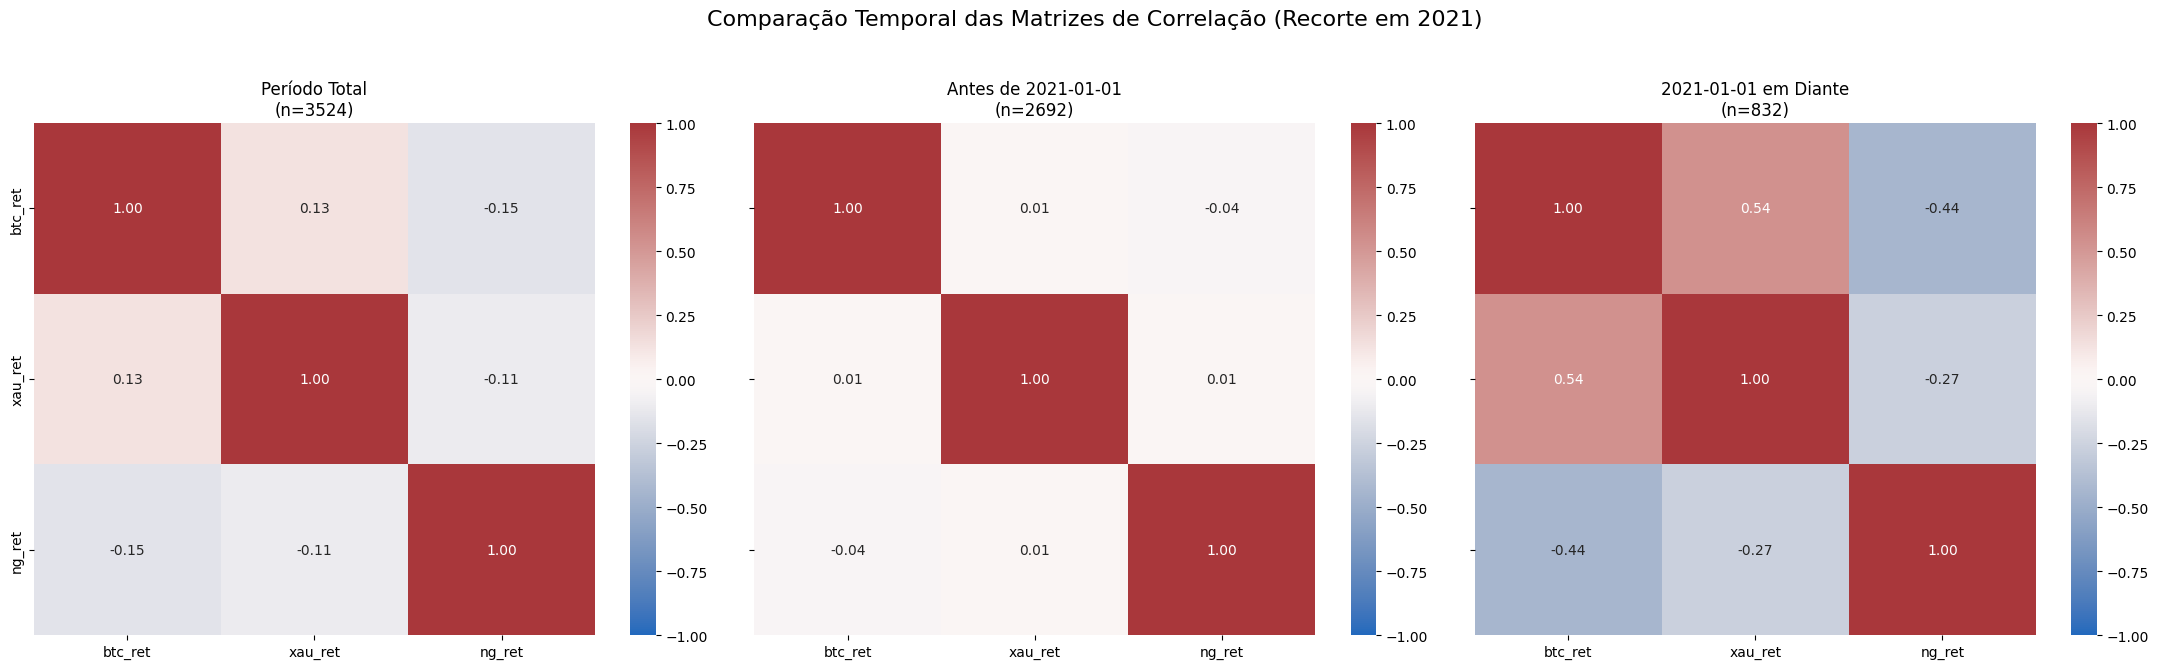

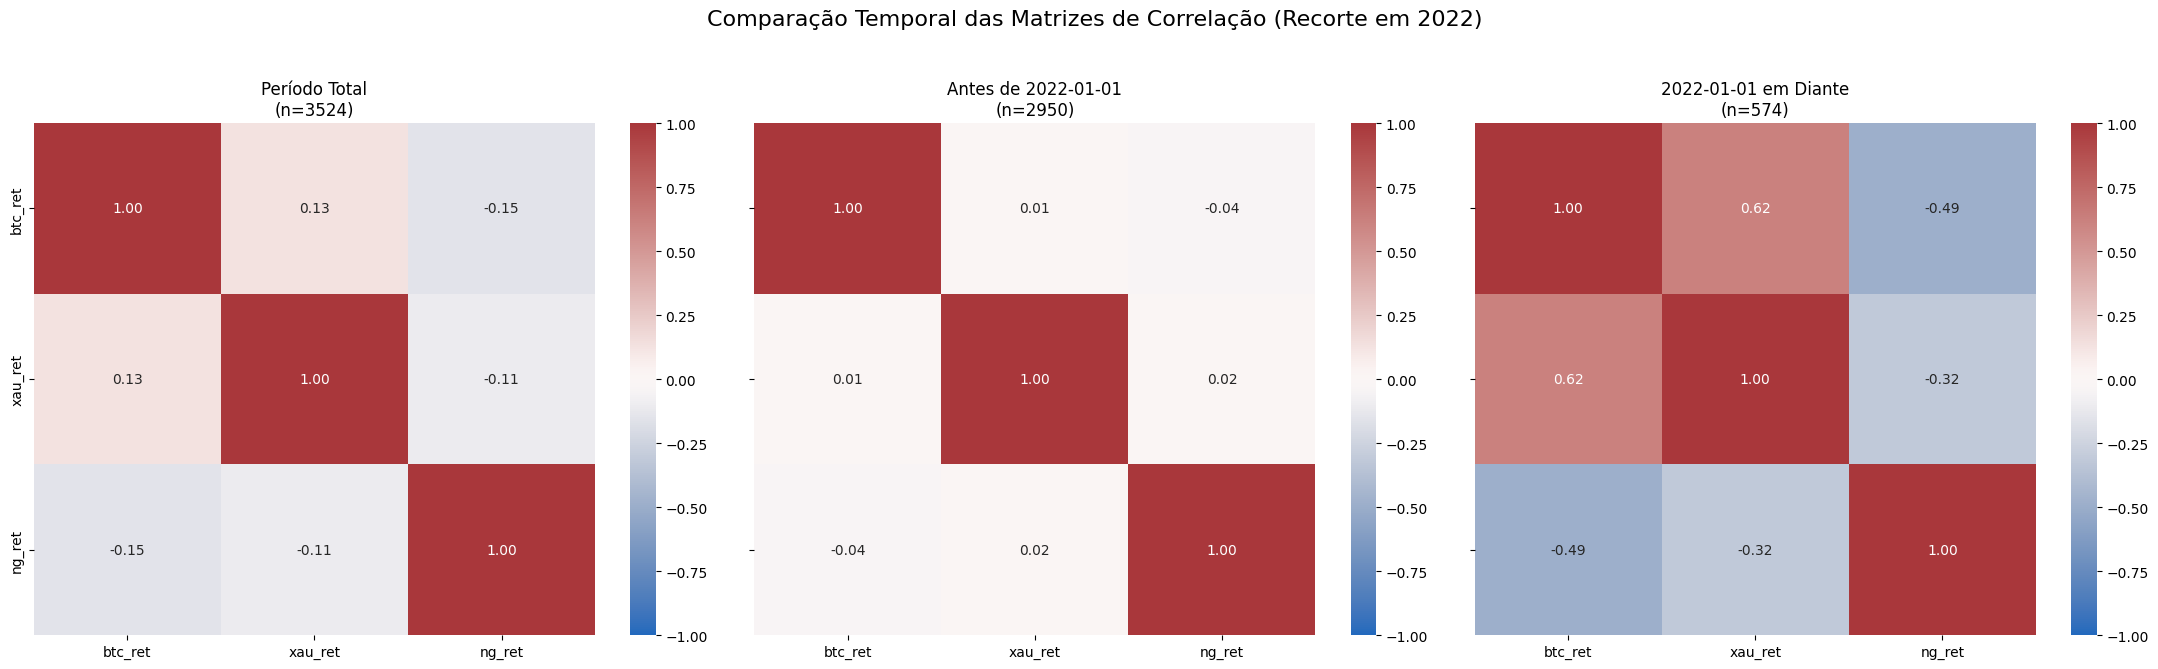

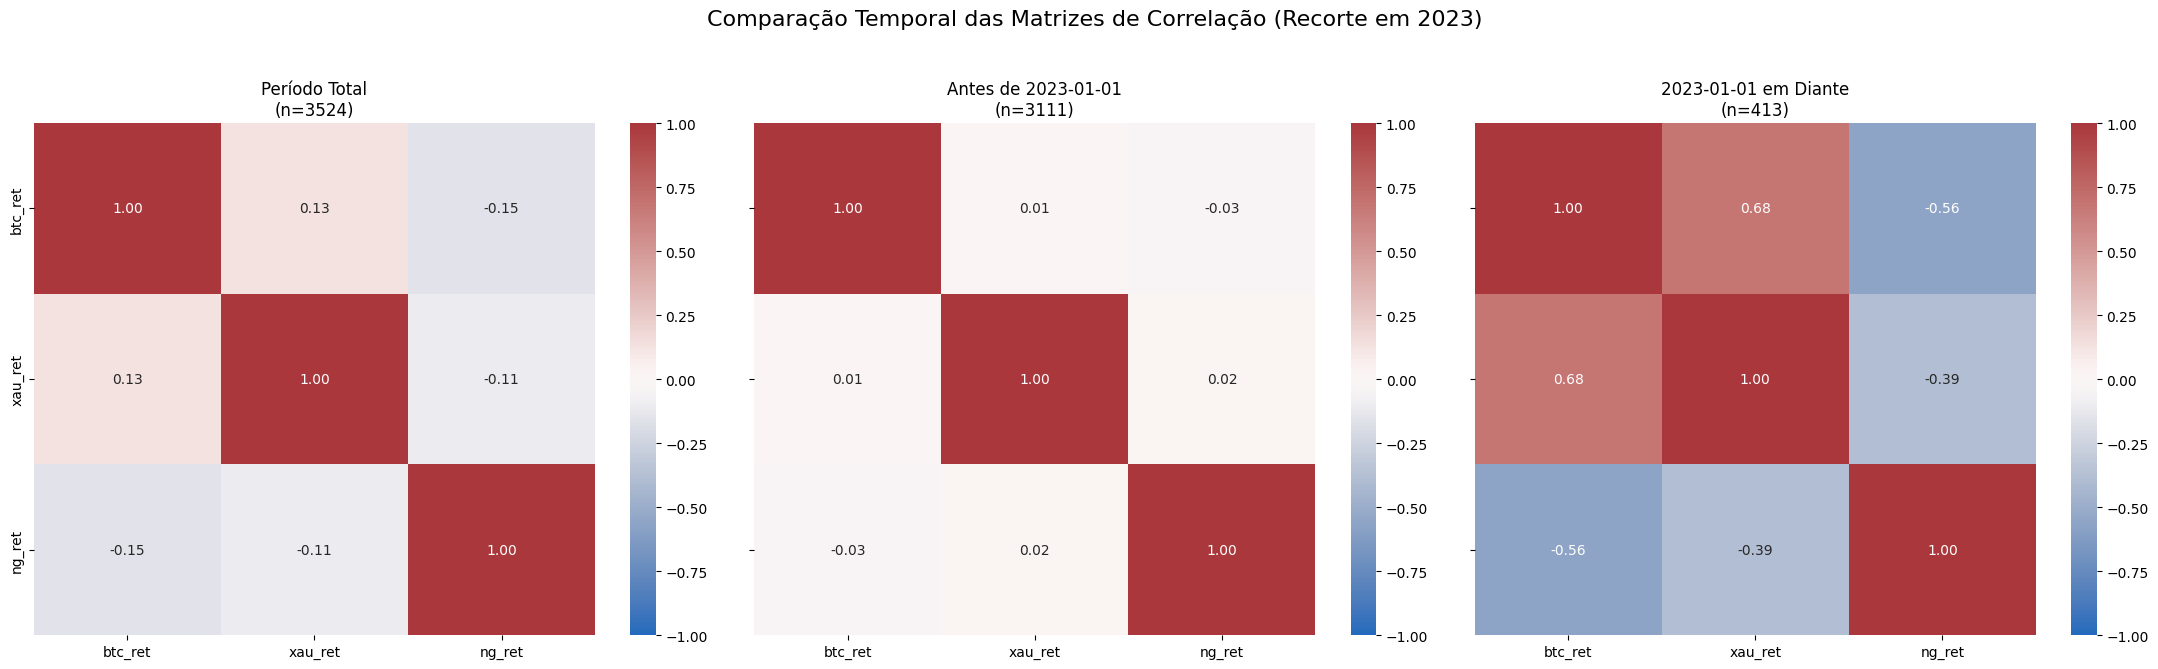

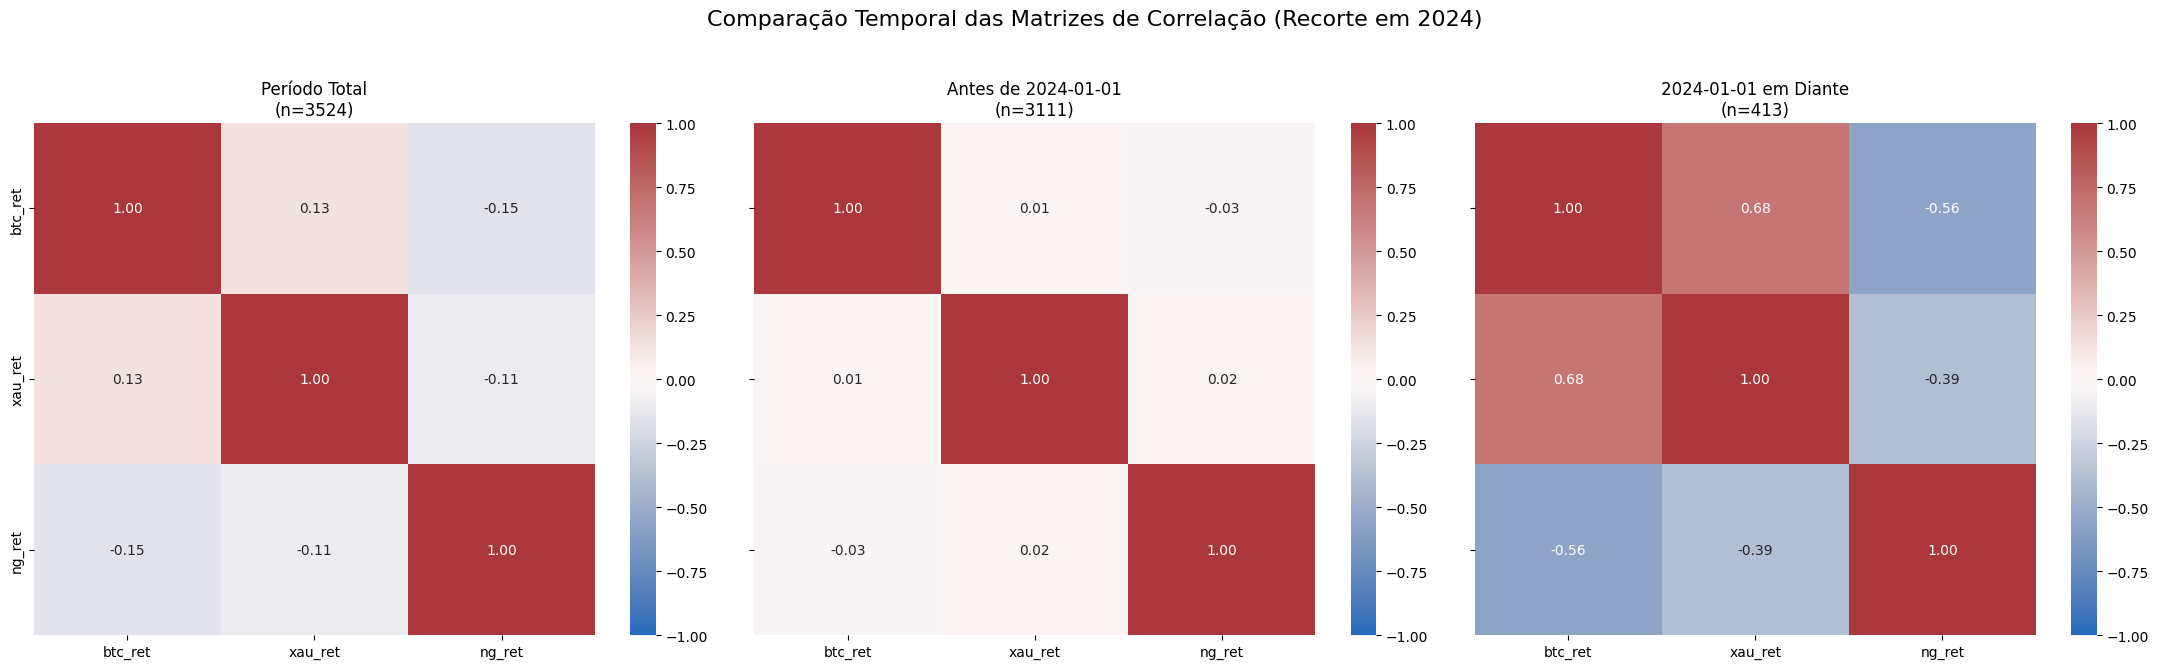

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. FUNÇÃO DE CARREGAMENTO E LIMPEZA (Já validada) ---
def load_and_clean_data(file_path, symbol):
    """
    Carrega os CSVs formatados em português (DD.MM.YYYY, decimal ',', milhar '.')
    """
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'], # Carrega apenas colunas necessárias
            parse_dates=['Data'],
            dayfirst=True # Indica que o formato é DD/MM/YYYY
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')] # Remove datas duplicadas
        return data
    except Exception as e:
        # print(f"Erro ao carregar {file_path}: {e}") # Descomente para debug
        return None

# --- 2. CARREGAMENTO E ALINHAMENTO (MÉTODO 'INNER') ---
print("Carregando e alinhando dados (Método 'INNER')...")
files = {
    'btc': 'BTC.csv',
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}
image_files = [] # Lista para armazenar os nomes dos arquivos de imagem

df_list = []
for symbol, file_path in files.items():
    # Verifica se o arquivo existe (importante para o seu ambiente local)
    if not os.path.exists(file_path):
        print(f"AVISO: Arquivo {file_path} não encontrado. Pulando este ativo.")
        continue
    df = load_and_clean_data(file_path, symbol)
    if df is not None:
        df_list.append(df)

if len(df_list) < 3:
    print("ERRO: Não foi possível carregar todos os 3 arquivos. Análise cancelada.")
    print("Por favor, verifique se os 3 arquivos CSV estão na mesma pasta que o script.")
else:
    # 'inner': Mantém apenas as datas que existem em TODOS os 3 arquivos.
    data_aligned_inner = pd.concat(df_list, axis=1, join='inner')
    data_aligned_inner.sort_index(inplace=True)

    # Garante que todos os dados são numéricos e remove NaNs
    for col in data_aligned_inner.columns:
        data_aligned_inner[col] = pd.to_numeric(data_aligned_inner[col], errors='coerce')
    data_aligned_inner.dropna(inplace=True)

    print(f"Dados prontos. {len(data_aligned_inner)} dias de negociação em comum encontrados.")

    # --- 3. CÁLCULO DOS RETORNOS DIÁRIOS (FEITO UMA SÓ VEZ) ---
    print("\nCalculando retornos diários (base 'INNER')...")
    returns_inner = data_aligned_inner.pct_change().dropna()
    returns_inner.columns = [f'{col}_ret' for col in returns_inner.columns]
    corr_total = returns_inner.corr()

    # --- 4. LISTA DE RECORTES PARA ANALISAR ---
    # Adicionando os novos recortes de 2022, 2023 e 2024
    split_dates = [
        '2018-01-01', 
        '2019-01-01', 
        '2020-01-01', 
        '2021-01-01',
        '2022-01-01', # Novo
        '2023-01-01', # Novo
        '2024-01-01'  # Novo
    ]

    print("\n--- MATRIZ (PERÍODO TOTAL) ---")
    print(corr_total)

    # Loop para criar cada análise de recorte
    for date_str in split_dates:
        year = date_str.split('-')[0]
        print(f"\n\n--- ANÁLISE: Recorte em {date_str} ---")
        
        # Separa os dataframes de retorno
        returns_pre = returns_inner[returns_inner.index < date_str]
        returns_post = returns_inner[returns_inner.index >= date_str]
        
        # Calcula as matrizes de correlação
        corr_pre = returns_pre.corr()
        corr_post = returns_post.corr()
        
        # --- Apresentação dos Resultados ---
        print(f"\n--- MATRIZ (ANTES DE {date_str}) ---")
        print(corr_pre)
        print(f"\n--- MATRIZ ({date_str} EM DIANTE) ---")
        print(corr_post)
        
        # --- Plotagem ---
        fig, axes = plt.subplots(1, 3, figsize=(22, 7), sharey=True)
        
        # Plot 1: Período Total
        sns.heatmap(corr_total, ax=axes[0], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[0].set_title(f'Período Total\n(n={len(returns_inner)})')
        
        # Plot 2: Antes do Recorte
        # Adicionado um 'if' para evitar erro se 'returns_pre' estiver vazio (ex: primeiro ano)
        if not returns_pre.empty:
            sns.heatmap(corr_pre, ax=axes[1], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[1].set_title(f'Antes de {date_str}\n(n={len(returns_pre)})')
        
        # Plot 3: Depois do Recorte
        if not returns_post.empty:
            sns.heatmap(corr_post, ax=axes[2], annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
        axes[2].set_title(f'{date_str} em Diante\n(n={len(returns_post)})')
        
        plt.suptitle(f'Comparação Temporal das Matrizes de Correlação (Recorte em {year})', fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta layout
        
        # Salva o gráfico com um nome de arquivo único
        filename = f'correlation_comparison_{year}.png'
        plt.savefig(filename)
        image_files.append(filename)
        print(f"\nGráfico '{filename}' salvo.")

    print(f"\n\n--- Processo Concluído ---")
    print(f"Gráficos gerados: {', '.join(image_files)}")

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. FUNÇÃO DE CARREGAMENTO E LIMPEZA (Já validada) ---
def load_and_clean_data(file_path, symbol):
    """
    Carrega os CSVs formatados em português (DD.MM.YYYY, decimal ',', milhar '.')
    """
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'], # Carrega apenas colunas necessárias
            parse_dates=['Data'],
            dayfirst=True # Indica que o formato é DD/MM/YYYY
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')] # Remove datas duplicadas
        return data
    except Exception as e:
        # print(f"Erro ao carregar {file_path}: {e}") # Descomente para debug
        return None

# --- 2. CARREGAMENTO E ALINHAMENTO (MÉTODO 'INNER') ---
print("Carregando e alinhando dados (Método 'INNER')...")
files = {
    'btc': 'BTC.csv',
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}
image_files = [] # Lista para armazenar os nomes dos arquivos de imagem

df_list = []
for symbol, file_path in files.items():
    # Verifica se o arquivo existe (importante para o seu ambiente local)
    if not os.path.exists(file_path):
        print(f"AVISO: Arquivo {file_path} não encontrado. Pulando este ativo.")
        continue
    df = load_and_clean_data(file_path, symbol)
    if df is not None:
        df_list.append(df)

if len(df_list) < 3:
    print("ERRO: Não foi possível carregar todos os 3 arquivos. Análise cancelada.")
    print("Por favor, verifique se os 3 arquivos CSV estão na mesma pasta que o script.")
else:
    # 'inner': Mantém apenas as datas que existem em TODOS os 3 arquivos.
    data_aligned_inner = pd.concat(df_list, axis=1, join='inner')
    data_aligned_inner.sort_index(inplace=True)

    # Garante que todos os dados são numéricos e remove NaNs
    for col in data_aligned_inner.columns:
        data_aligned_inner[col] = pd.to_numeric(data_aligned_inner[col], errors='coerce')
    data_aligned_inner.dropna(inplace=True)

    print(f"Dados prontos. {len(data_aligned_inner)} dias de negociação em comum encontrados.")

    # --- 3. CÁLCULO DOS RETORNOS DIÁRIOS (FEITO UMA SÓ VEZ) ---
    print("\nCalculando retornos diários (base 'INNER')...")
    returns_inner = data_aligned_inner.pct_change().dropna()
    returns_inner.columns = [f'{col}_ret' for col in returns_inner.columns]
    
    # Adiciona uma coluna 'year' para facilitar o filtro
    returns_inner['year'] = returns_inner.index.year

    # --- 4. ANÁLISE E PLOTAGEM ANO A ANO (DENTRO DO LOOP) ---
    
    # Lista de anos de interesse (desde 2018)
    start_year = max(2018, returns_inner['year'].min())
    end_year = returns_inner['year'].max()
    years_to_analyze = range(start_year, end_year + 1)
    
    print(f"Gerando matrizes de correlação intra-anuais de {start_year} a {end_year}...")

    for year in years_to_analyze:
        print(f"\n\n--- ANÁLISE: ANO {year} ---")
        
        # Filtra os retornos APENAS para o ano corrente
        returns_year = returns_inner[returns_inner['year'] == year]
        
        if returns_year.empty:
            print(f"Sem dados para o ano {year}. Nenhum gráfico será gerado.")
            continue
            
        # Calcula a matriz de correlação APENAS para aquele ano
        corr_year = returns_year[['btc_ret', 'xau_ret', 'ng_ret']].corr()
        
        print(f"Matriz de Correlação (Apenas {year}), n={len(returns_year)}:")
        print(corr_year)
        
        # --- 5. PLOTAGEM (DENTRO DO LOOP) ---
        print(f"Gerando gráfico para o ano {year}...")
        
        # Cria uma nova figura para este ano
        fig, ax = plt.subplots(figsize=(8, 6)) 
        
        sns.heatmap(
            corr_year, 
            ax=ax, 
            annot=True,     # Escreve os números dentro das células
            cmap='vlag',    # Paleta de cores (vermelho-azul)
            fmt='.2f',      # Formato com 2 casas decimais
            vmin=-1,        # Trava o limite inferior da cor em -1
            vmax=1          # Trava o limite superior da cor em +1
        )
        ax.set_title(f'Matriz de Correlação (Apenas {year}), n={len(returns_year)}')
        
        # Salva o gráfico com um nome de arquivo único
        filename = f'correlation_matrix_{year}.png'
        plt.savefig(filename)
        plt.close(fig) # Fecha a figura para economizar memória
        
        image_files.append(filename)
        print(f"Gráfico '{filename}' salvo.")

    print(f"\n\n--- Processo Concluído ---")
    print(f"Gráficos gerados: {', '.join(image_files)}")

Carregando e alinhando dados (Método 'INNER')...
Dados prontos. 3525 dias de negociação em comum encontrados.

Calculando retornos diários (base 'INNER')...
Gerando matrizes de correlação intra-anuais de 2018 a 2025...


--- ANÁLISE: ANO 2018 ---
Matriz de Correlação (Apenas 2018), n=259:
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000 -0.040149 -0.068226
xau_ret -0.040149  1.000000 -0.059973
ng_ret  -0.068226 -0.059973  1.000000
Gerando gráfico para o ano 2018...
Gráfico 'correlation_matrix_2018.png' salvo.


--- ANÁLISE: ANO 2019 ---
Matriz de Correlação (Apenas 2019), n=260:
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.186558  0.024067
xau_ret  0.186558  1.000000 -0.102098
ng_ret   0.024067 -0.102098  1.000000
Gerando gráfico para o ano 2019...
Gráfico 'correlation_matrix_2019.png' salvo.


--- ANÁLISE: ANO 2020 ---
Matriz de Correlação (Apenas 2020), n=260:
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.274921 -0.001081
xau_ret  0.274921  1.000000 

Carregando e alinhando dados (Método 'INNER')...
Dados prontos. 3525 dias de negociação em comum encontrados.

Calculando retornos diários (base 'INNER')...


--- ANÁLISE DE OUTLIER (Período 2018-2025) ---

--- MATRIZ (Período 2018-2025, COM 2024) ---
n = 1611
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.433841 -0.338569
xau_ret  0.433841  1.000000 -0.203933
ng_ret  -0.338569 -0.203933  1.000000

--- MATRIZ (Período 2018-2025, SEM 2024) ---
n = 1413
          btc_ret   xau_ret    ng_ret
btc_ret  1.000000  0.099646 -0.001842
xau_ret  0.099646  1.000000  0.044031
ng_ret  -0.001842  0.044031  1.000000

Gerando gráfico comparativo...
Gráfico 'correlation_outlier_analysis_2024.png' salvo.

--- Processo Concluído ---


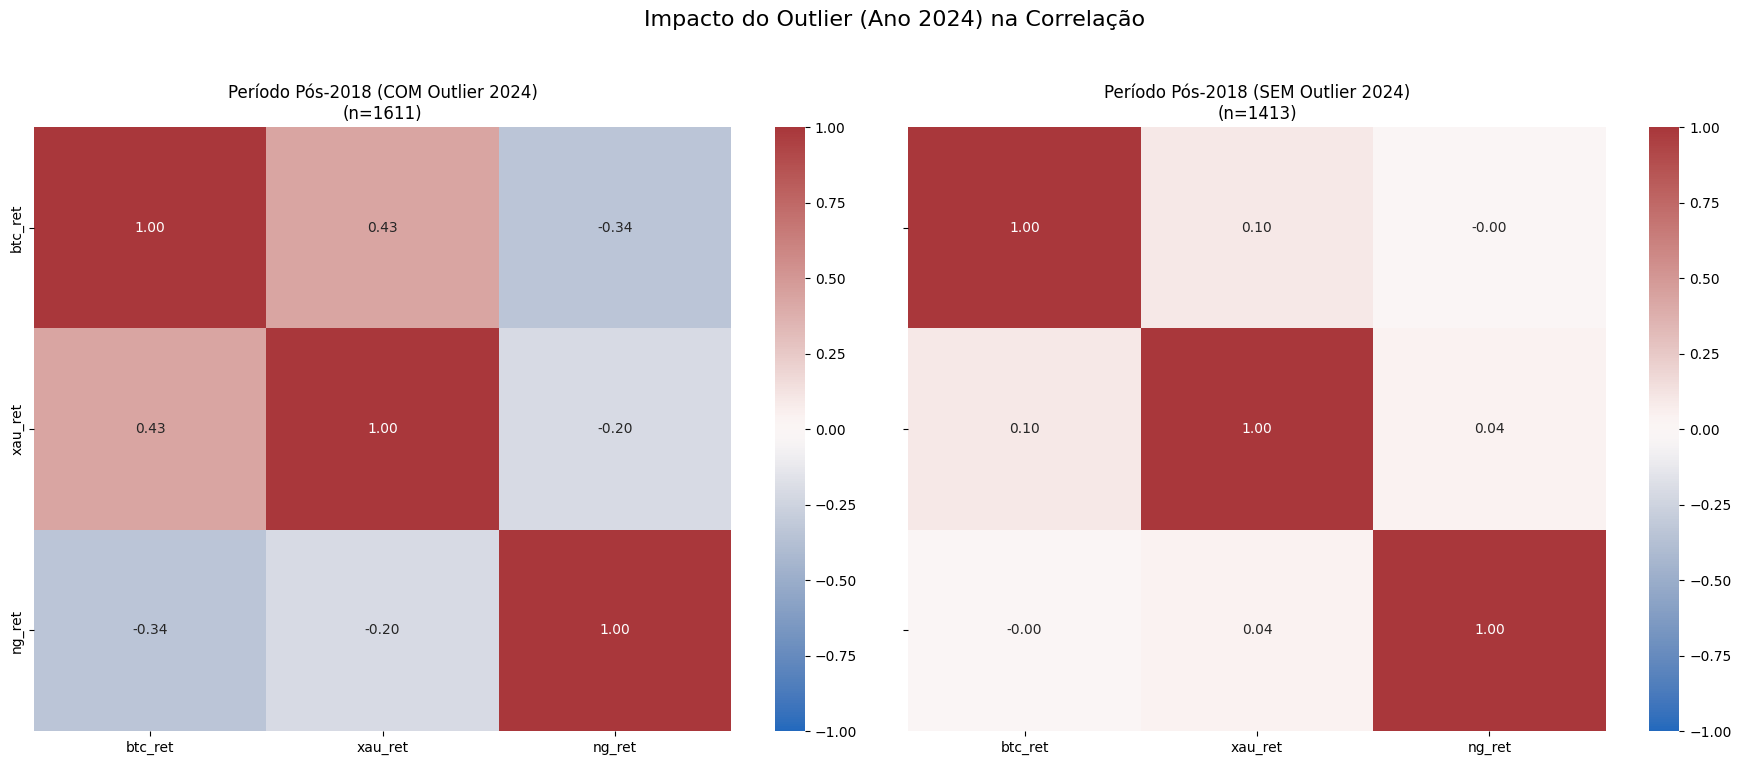

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. FUNÇÃO DE CARREGAMENTO E LIMPEZA (Já validada) ---
def load_and_clean_data(file_path, symbol):
    """
    Carrega os CSVs formatados em português (DD.MM.YYYY, decimal ',', milhar '.')
    """
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'], # Carrega apenas colunas necessárias
            parse_dates=['Data'],
            dayfirst=True # Indica que o formato é DD/MM/YYYY
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')] # Remove datas duplicadas
        return data
    except Exception as e:
        # print(f"Erro ao carregar {file_path}: {e}") # Descomente para debug
        return None

# --- 2. CARREGAMENTO E ALINHAMENTO (MÉTODO 'INNER') ---
print("Carregando e alinhando dados (Método 'INNER')...")
files = {
    'btc': 'BTC.csv',
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}
image_files = [] # Lista para armazenar os nomes dos arquivos de imagem

df_list = []
for symbol, file_path in files.items():
    # Verifica se o arquivo existe (importante para o seu ambiente local)
    if not os.path.exists(file_path):
        print(f"AVISO: Arquivo {file_path} não encontrado. Pulando este ativo.")
        continue
    df = load_and_clean_data(file_path, symbol)
    if df is not None:
        df_list.append(df)

if len(df_list) < 3:
    print("ERRO: Não foi possível carregar todos os 3 arquivos. Análise cancelada.")
    print("Por favor, verifique se os 3 arquivos CSV estão na mesma pasta que o script.")
else:
    # 'inner': Mantém apenas as datas que existem em TODOS os 3 arquivos.
    data_aligned_inner = pd.concat(df_list, axis=1, join='inner')
    data_aligned_inner.sort_index(inplace=True)

    # Garante que todos os dados são numéricos e remove NaNs
    for col in data_aligned_inner.columns:
        data_aligned_inner[col] = pd.to_numeric(data_aligned_inner[col], errors='coerce')
    data_aligned_inner.dropna(inplace=True)

    print(f"Dados prontos. {len(data_aligned_inner)} dias de negociação em comum encontrados.")

    # --- 3. CÁLCULO DOS RETORNOS DIÁRIOS (FEITO UMA SÓ VEZ) ---
    print("\nCalculando retornos diários (base 'INNER')...")
    returns_inner = data_aligned_inner.pct_change().dropna()
    returns_inner.columns = [f'{col}_ret' for col in returns_inner.columns]
    
    # Adiciona uma coluna 'year' para facilitar o filtro
    returns_inner['year'] = returns_inner.index.year

    # --- 4. CÁLCULO DA MÉDIA SEM O OUTLIER ---
    
    # Período de interesse: 2018 em diante
    start_date = '2018-01-01'
    
    # 1. Período "Pós-2018" (INCLUINDO o outlier 2024)
    returns_post_2018_COM_outlier = returns_inner[returns_inner.index >= start_date]
    corr_post_2018_COM_outlier = returns_post_2018_COM_outlier[['btc_ret', 'xau_ret', 'ng_ret']].corr()
    
    # 2. Período "Pós-2018" (REMOVENDO o outlier 2024)
    returns_post_2018_SEM_outlier = returns_inner[
        (returns_inner.index >= start_date) & (returns_inner['year'] != 2024)
    ]
    corr_post_2018_SEM_outlier = returns_post_2018_SEM_outlier[['btc_ret', 'xau_ret', 'ng_ret']].corr()

    # --- 5. APRESENTAÇÃO DOS RESULTADOS E GRÁFICO ---
    
    print("\n\n--- ANÁLISE DE OUTLIER (Período 2018-2025) ---")
    
    print(f"\n--- MATRIZ (Período 2018-2025, COM 2024) ---")
    print(f"n = {len(returns_post_2018_COM_outlier)}")
    print(corr_post_2018_COM_outlier)
    
    print(f"\n--- MATRIZ (Período 2018-2025, SEM 2024) ---")
    print(f"n = {len(returns_post_2018_SEM_outlier)}")
    print(corr_post_2018_SEM_outlier)
    
    # --- Plotagem Comparativa ---
    print("\nGerando gráfico comparativo...")
    fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True) # 1 linha, 2 colunas
    
    # Plot 1: COM Outlier
    sns.heatmap(
        corr_post_2018_COM_outlier, 
        ax=axes[0], 
        annot=True, 
        cmap='vlag', 
        fmt='.2f', 
        vmin=-1, 
        vmax=1
    )
    axes[0].set_title(f'Período Pós-2018 (COM Outlier 2024)\n(n={len(returns_post_2018_COM_outlier)})')
    
    # Plot 2: SEM Outlier
    sns.heatmap(
        corr_post_2018_SEM_outlier, 
        ax=axes[1], 
        annot=True, 
        cmap='vlag', 
        fmt='.2f', 
        vmin=-1, 
        vmax=1
    )
    axes[1].set_title(f'Período Pós-2018 (SEM Outlier 2024)\n(n={len(returns_post_2018_SEM_outlier)})')
    
    plt.suptitle('Impacto do Outlier (Ano 2024) na Correlação', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta layout
    
    filename = 'correlation_outlier_analysis_2024.png'
    plt.savefig(filename)
    image_files.append(filename)
    
    print(f"Gráfico '{filename}' salvo.")
    print(f"\n--- Processo Concluído ---")

In [2]:
import yfinance as yf
import pandas as pd
import os

# 1. DEFINIÇÃO DOS ATIVOS MACRO
# Tickers do Yahoo Finance
macro_tickers = {
    'vix': '^VIX',       # Índice de Volatilidade (Medo)
    'juros_10a': '^TNX',   # Juros de 10 anos dos EUA (Custo do Dinheiro)
    'dolar': 'DX-Y.NYB', # Índice do Dólar (Força do Dólar)
    'petroleo': 'CL=F'     # Petróleo Bruto WTI (Inflação)
}

# 2. DEFINIÇÃO DO PERÍODO
# Vamos pegar desde 2010 para ter certeza que cobre todo o período do seu BTC.csv
start_date = '2010-01-01'
end_date = '2025-11-02' # Usando uma data futura para pegar "até hoje"

print(f"Baixando dados macro de {start_date} até {end_date}...")

# 3. BAIXAR OS DADOS
try:
    # Baixa os dados
    data_raw = yf.download(list(macro_tickers.values()), 
                           start=start_date, 
                           end=end_date)
    
    # 4. LIMPEZA E ORGANIZAÇÃO
    print("Limpando e organizando os dados...")
    
    # Vamos usar apenas o preço de fechamento ('Close')
    data_macro = data_raw['Close']
    
    # Renomear as colunas para nomes fáceis
    data_macro.columns = macro_tickers.keys()
    
    # Dados macro não operam no fim de semana. 
    # Vamos preencher os buracos (NaN) com o último valor conhecido (ffill).
    data_macro.ffill(inplace=True)
    
    # Remove qualquer NaN que sobrou no início
    data_macro.dropna(inplace=True)
    
    # 5. SALVAR EM CSV
    output_file = 'macro_data.csv'
    data_macro.to_csv(output_file)
    
    print(f"\nSucesso! Dados macro salvos em '{output_file}'")
    print("Últimos 5 dias de dados:")
    print(data_macro.tail())

except Exception as e:
    print(f"\nERRO: Não foi possível baixar os dados.")
    print(f"Verifique sua conexão com a internet ou os tickers: {e}")

Baixando dados macro de 2010-01-01 até 2025-11-02...


C:\Users\kraus\AppData\Local\Temp\ipykernel_35204\2421889523.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(list(macro_tickers.values()),
[*********************100%***********************]  4 of 4 completed

Limpando e organizando os dados...

Sucesso! Dados macro salvos em 'macro_data.csv'
Últimos 5 dias de dados:
                  vix  juros_10a  dolar   petroleo
Date                                              
2025-10-27  61.310001  98.779999  3.997  15.790000
2025-10-28  60.150002  98.690002  3.983  16.420000
2025-10-29  60.480000  99.220001  4.058  16.920000
2025-10-30  60.570000  99.529999  4.093  16.910000
2025-10-31  60.980000  99.716003  4.101  17.440001



C:\Users\kraus\AppData\Local\Temp\ipykernel_35204\2421889523.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_macro.ffill(inplace=True)
C:\Users\kraus\AppData\Local\Temp\ipykernel_35204\2421889523.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_macro.dropna(inplace=True)


In [3]:
import pandas as pd
import numpy as np
import os

# --- (Função de carregamento que já validamos) ---
def load_and_clean_data(file_path, symbol):
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'],
            parse_dates=['Data'],
            dayfirst=True
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')]
        return data
    except Exception as e:
        print(f"Erro ao carregar {file_path}: {e}")
        return None
# --- (Fim da função) ---


# 1. DEFINIÇÃO DAS "ONDAS" (REGIMES)
# Estas datas são aproximadas, baseadas na nossa pesquisa de ciclos
# Formato: 'YYYY-MM-DD'
ciclos = {
    'data_baixa_1': pd.to_datetime('2013-12-01'), # Pico Mt. Gox
    'data_onda_2': pd.to_datetime('2016-01-01'),  # Fim da Baixa 1
    'data_baixa_2': pd.to_datetime('2017-12-15'), # Pico 20k
    'data_onda_3': pd.to_datetime('2020-03-15'),  # Fundo COVID
    'data_baixa_3': pd.to_datetime('2021-11-10'), # Pico 68k
    'data_onda_4': pd.to_datetime('2022-11-20'),  # Fundo FTX
}

# 2. CARREGAR O SEU ARQUIVO BTC.csv
btc_file = 'BTC.csv'
print(f"Carregando '{btc_file}'...")
if not os.path.exists(btc_file):
    print(f"ERRO: Arquivo '{btc_file}' não encontrado. Coloque-o na mesma pasta.")
else:
    df_btc = load_and_clean_data(btc_file, 'btc_price')
    
    if df_btc is not None:
        print("Definindo os rótulos (labels) das ondas...")
        
        # 3. CRIAR A COLUNA "ciclo_btc"
        
        # Lista de condições (da mais recente para a mais antiga)
        conditions = [
            (df_btc.index >= ciclos['data_onda_4']),
            (df_btc.index >= ciclos['data_baixa_3']),
            (df_btc.index >= ciclos['data_onda_3']),
            (df_btc.index >= ciclos['data_baixa_2']),
            (df_btc.index >= ciclos['data_onda_2']),
            (df_btc.index >= ciclos['data_baixa_1']),
        ]
        
        # Lista de rótulos (na mesma ordem)
        labels = [
            'Onda 4 (ETFs)',
            'Baixa 3 (FTX/Juros)',
            'Onda 3 (Pandemia)',
            'Baixa 2 (Inverno 2018)',
            'Onda 2 (Popularizacao)',
            'Baixa 1 (Mt. Gox)',
        ]
        
        # A função np.select aplica os rótulos com base nas condições
        # O 'default' é para qualquer data ANTES da primeira condição
        df_btc['ciclo_btc'] = np.select(conditions, labels, default='Onda 1 (Inicio)')
        
        # 4. SALVAR O NOVO ARQUIVO
        output_file = 'BTC_com_ciclos.csv'
        df_btc.to_csv(output_file)
        
        print(f"\nSucesso! Novo arquivo salvo como '{output_file}'")
        print("Verificação dos ciclos (últimos 10 dias):")
        print(df_btc.tail(10))
        
        print("\nContagem de dias por ciclo:")
        print(df_btc['ciclo_btc'].value_counts())

Carregando 'BTC.csv'...
Definindo os rótulos (labels) das ondas...

Sucesso! Novo arquivo salvo como 'BTC_com_ciclos.csv'
Verificação dos ciclos (últimos 10 dias):
            btc_price        ciclo_btc
Data                                  
2010-07-27        0.1  Onda 1 (Inicio)
2010-07-26        0.1  Onda 1 (Inicio)
2010-07-25        0.1  Onda 1 (Inicio)
2010-07-24        0.1  Onda 1 (Inicio)
2010-07-23        0.1  Onda 1 (Inicio)
2010-07-22        0.1  Onda 1 (Inicio)
2010-07-21        0.1  Onda 1 (Inicio)
2010-07-20        0.1  Onda 1 (Inicio)
2010-07-19        0.1  Onda 1 (Inicio)
2010-07-18        0.1  Onda 1 (Inicio)

Contagem de dias por ciclo:
ciclo_btc
Onda 1 (Inicio)           1232
Baixa 2 (Inverno 2018)     821
Baixa 1 (Mt. Gox)          761
Onda 2 (Popularizacao)     714
Onda 3 (Pandemia)          605
Onda 4 (ETFs)              587
Baixa 3 (FTX/Juros)        280
Name: count, dtype: int64


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- 1. FUNÇÕES DE CARREGAMENTO ---

def load_clean_original_data(file_path, symbol):
    """Carrega os CSVs originais (XAU, NG)"""
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'],
            parse_dates=['Data'],
            dayfirst=True
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')]
        return data
    except Exception as e:
        print(f"Erro ao carregar {file_path}: {e}")
        return None

def load_standard_csv(file_path):
    """Carrega os novos CSVs (BTC_com_ciclos, macro_data)"""
    try:
        data = pd.read_csv(
            file_path,
            parse_dates=['Data'],
            index_col='Data'
        )
        return data
    except Exception as e:
        print(f"Erro ao carregar {file_path}: {e}")
        return None

# --- 2. VERIFICAÇÃO E CARREGAMENTO DOS 4 ARQUIVOS ---
print("Carregando todos os 4 arquivos de dados...")

files_to_check = ['BTC_com_ciclos.csv', 'macro_data.csv', 'XAU-USD.csv', 'Gas Natural Futures.csv']
if not all(os.path.exists(f) for f in files_to_check):
    print("\n--- ERRO ---")
    print("Um ou mais arquivos necessários não foram encontrados.")
    print("Por favor, execute os dois scripts anteriores primeiro ('baixar_macro.py' e 'marcar_ondas_btc.py')")
    print("E certifique-se que 'XAU-USD.csv' e 'Gas Natural Futures.csv' estão na pasta.")
    # Parar a execução (simulado)
    # Em um script real, você colocaria um 'exit()' aqui
    df_btc = None 
else:
    df_btc = load_standard_csv('BTC_com_ciclos.csv')
    df_macro = load_standard_csv('macro_data.csv')
    df_xau = load_clean_original_data('XAU-USD.csv', 'xau')
    df_ng = load_clean_original_data('Gas Natural Futures.csv', 'ng')

# --- 3. MERGE, LIMPEZA E CÁLCULO DE RETORNOS ---
if df_btc is not None: # Prossegue apenas se os arquivos foram carregados
    print("Alinhando todos os dados (join 'inner')...")
    
    # Junta todos os 4 dataframes. 'inner' garante que só temos dias
    # em que TODOS os 4 ativos (BTC, XAU, NG, Macro) tiveram dados.
    df_master = pd.concat([df_btc, df_xau, df_ng, df_macro], axis=1, join='inner')
    
    # Define os regimes macro
    print("Definindo regimes macroeconômicos...")
    # Regra simples: VIX > 20 é "Risk-Off" (Alto Medo)
    vix_threshold = 20
    df_master['macro_regime'] = np.where(df_master['vix'] > vix_threshold, 
                                        'Risk-Off (VIX > 20)', 
                                        'Risk-On (VIX <= 20)')

    # Calcula os retornos de todos os ativos de preço
    print("Calculando retornos diários...")
    df_returns = df_master[['btc_price', 'xau', 'ng', 'petroleo']].pct_change()
    df_returns.columns = ['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']
    
    # Junta os rótulos de regime ao dataframe de retornos
    df_analysis = df_returns.join(df_master[['ciclo_btc', 'macro_regime']]).dropna()
    
    print(f"\nDados de análise prontos. {len(df_analysis)} dias de negociação em comum encontrados.")

    # --- 4. ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---
    print("\n\n--- ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---")
    
    # Pega todos os ciclos únicos que marcamos
    ciclos_unicos = df_analysis['ciclo_btc'].unique()
    
    for ciclo in sorted(ciclos_unicos):
        print(f"\n--- Matriz de Correlação (Ciclo: {ciclo}) ---")
        
        # Filtra os retornos apenas para este ciclo
        returns_ciclo = df_analysis[df_analysis['ciclo_btc'] == ciclo]
        
        if len(returns_ciclo) < 30: # Ignora se tiver muito poucos dados
            print(f" (n={len(returns_ciclo)} - Amostra muito pequena, pulando)")
            continue
            
        print(f" (n={len(returns_ciclo)} dias de negociação)")
        # Calcula a correlação dos ativos de interesse
        corr_ciclo = returns_ciclo[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
        print(corr_ciclo)

    # --- 5. ANÁLISE 2: CORRELAÇÃO POR REGIME MACRO (VIX) ---
    print("\n\n--- ANÁLISE 2: CORRELAÇÃO POR REGIME MACRO (VIX) ---")
    
    regimes_unicos = df_analysis['macro_regime'].unique()
    
    for regime in sorted(regimes_unicos):
        print(f"\n--- Matriz de Correlação (Regime: {regime}) ---")
        
        # Filtra os retornos apenas para este regime
        returns_regime = df_analysis[df_analysis['macro_regime'] == regime]
        
        print(f" (n={len(returns_regime)} dias de negociação)")
        corr_regime = returns_regime[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
        print(corr_regime)

    # --- 6. ANÁLISE 3: CORRELAÇÃO COMBINADA (Opcional, mas poderosa) ---
    print("\n\n--- ANÁLISE 3: CORRELAÇÃO COMBINADA (Ciclo + Regime) ---")
    
    # Agrupa por ambos e calcula a correlação de btc_ret vs xau_ret
    # groupby()
    
    for ciclo in sorted(ciclos_unicos):
        for regime in sorted(regimes_unicos):
            print(f"\n--- Matriz (Ciclo: {ciclo} // Regime: {regime}) ---")
            
            # Filtra por AMBOS
            returns_combo = df_analysis[
                (df_analysis['ciclo_btc'] == ciclo) & 
                (df_analysis['macro_regime'] == regime)
            ]
            
            if len(returns_combo) < 30: # Ignora se tiver muito poucos dados
                print(f" (n={len(returns_combo)} - Amostra muito pequena, pulando)")
                continue
                
            print(f" (n={len(returns_combo)} dias de negociação)")
            corr_combo = returns_combo[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
            print(corr_combo)
            
    print("\n\n--- Processo Concluído ---")

Carregando todos os 4 arquivos de dados...
Alinhando todos os dados (join 'inner')...
Definindo regimes macroeconômicos...
Calculando retornos diários...

Dados de análise prontos. 3449 dias de negociação em comum encontrados.


--- ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---

--- Matriz de Correlação (Ciclo: Baixa 1 (Mt. Gox)) ---
 (n=525 dias de negociação)
               btc_ret   xau_ret    ng_ret  petroleo_ret
btc_ret       1.000000 -0.053092 -0.112553      0.043227
xau_ret      -0.053092  1.000000  0.002983      0.075363
ng_ret       -0.112553  0.002983  1.000000      0.013074
petroleo_ret  0.043227  0.075363  0.013074      1.000000

--- Matriz de Correlação (Ciclo: Baixa 2 (Inverno 2018)) ---
 (n=563 dias de negociação)
               btc_ret   xau_ret    ng_ret  petroleo_ret
btc_ret       1.000000  0.148325  0.001458     -0.150875
xau_ret       0.148325  1.000000 -0.054833      0.114093
ng_ret        0.001458 -0.054833  1.000000     -0.083572
petroleo_ret -0.150875  0.114093

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# --- 1. FUNÇÕES DE CARREGAMENTO (Já validadas) ---

def load_clean_original_data(file_path, symbol):
    """Carrega os CSVs originais (XAU, NG)"""
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'],
            parse_dates=['Data'],
            dayfirst=True
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')]
        return data
    except Exception as e:
        print(f"ERRO AO CARREGAR: {file_path} - {e}")
        return None

def load_standard_csv(file_path):
    """Carrega os novos CSVs (BTC_com_ciclos, macro_data)"""
    try:
        data = pd.read_csv(
            file_path,
            parse_dates=['Data'],
            index_col='Data'
        )
        return data
    except Exception as e:
        print(f"ERRO AO CARREGAR: {file_path} - {e}")
        return None

# --- 2. CARREGAMENTO DOS 4 ARQUIVOS ---
print("Carregando todos os 4 arquivos de dados...")

files_to_load = {
    'btc': 'BTC_com_ciclos.csv',
    'macro': 'macro_data.csv',
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}

all_files_exist = True
for f in files_to_load.values():
    if not os.path.exists(f):
        print(f"ERRO CRÍTICO: Arquivo não encontrado: '{f}'")
        all_files_exist = False

if not all_files_exist:
    print("\nAnálise cancelada. Por favor, gere os arquivos faltantes ('baixar_macro.py', 'marcar_ondas_btc.py')")
else:
    # Carrega os arquivos
    df_btc = load_standard_csv(files_to_load['btc'])
    df_macro = load_standard_csv(files_to_load['macro'])
    df_xau = load_clean_original_data(files_to_load['xau'], 'xau')
    df_ng = load_clean_original_data(files_to_load['ng'], 'ng')

    # --- 3. MERGE, LIMPEZA E CÁLCULO DE RETORNOS ---
    if all(df is not None for df in [df_btc, df_macro, df_xau, df_ng]):
        
        print("Sucesso. Todos os arquivos carregados.")
        print("Alinhando todos os dados (join 'inner')...")
        
        df_master = pd.concat([df_btc, df_xau, df_ng, df_macro], axis=1, join='inner')
        
        print("Definindo regimes macroeconômicos (CORRIGIDO: Percentil 80)...")
        vix_threshold_p80 = df_master['vix'].quantile(0.80) 
        print(f"O limiar (threshold) de 'Pânico' (Percentil 80) é VIX = {vix_threshold_p80:.2f}")
        
        df_master['macro_regime'] = np.where(df_master['vix'] > vix_threshold_p80, 
                                            f'Risk-Off (VIX > P80)', 
                                            f'Risk-On (VIX <= P80)')
        
        print("Calculando retornos diários...")
        df_returns = df_master[['btc_price', 'xau', 'ng', 'petroleo']].pct_change()
        df_returns.columns = ['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']
        
        df_analysis = df_returns.join(df_master[['ciclo_btc', 'macro_regime']]).dropna()
        
        print(f"\nDados de análise prontos. {len(df_analysis)} dias de negociação em comum encontrados.")

        # Listas para armazenar dados para os gráficos
        plot_data_an1 = []
        plot_data_an2 = []
        plot_data_an3 = []

        # --- 4. ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---
        print("\n\n--- ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---")
        ciclos_unicos = sorted(df_analysis['ciclo_btc'].unique())
        
        for ciclo in ciclos_unicos:
            print(f"\n--- Matriz de Correlação (Ciclo: {ciclo}) ---")
            returns_ciclo = df_analysis[df_analysis['ciclo_btc'] == ciclo]
            n_obs = len(returns_ciclo)
            if n_obs < 30: 
                print(f" (n={n_obs} - Amostra pequena, pulando)")
                continue
            print(f" (n={n_obs} dias de negociação)")
            corr_ciclo = returns_ciclo[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
            print(corr_ciclo.to_string(float_format="%.3f"))
            
            # Salva dados para o Gráfico 1
            plot_data_an1.append({
                'Ciclo': ciclo,
                'BTC vs. XAU': corr_ciclo.loc['btc_ret', 'xau_ret'],
                'BTC vs. NG': corr_ciclo.loc['btc_ret', 'ng_ret'],
                'n': n_obs
            })

        # --- 5. ANÁLISE 2: CORRELAÇÃO POR REGIME MACRO (CORRIGIDA) ---
        print("\n\n--- ANÁLISE 2: CORRELAÇÃO POR REGIME MACRO (CORRIGIDA) ---")
        regimes_unicos = sorted(df_analysis['macro_regime'].unique())
        
        for regime in regimes_unicos:
            print(f"\n--- Matriz de Correlação (Regime: {regime}) ---")
            returns_regime = df_analysis[df_analysis['macro_regime'] == regime]
            n_obs = len(returns_regime)
            print(f" (n={n_obs} dias de negociação)")
            corr_regime = returns_regime[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
            print(corr_regime.to_string(float_format="%.3f"))

            # Salva dados para o Gráfico 2
            plot_data_an2.append({
                'Regime': regime,
                'BTC vs. XAU': corr_regime.loc['btc_ret', 'xau_ret'],
                'BTC vs. NG': corr_regime.loc['btc_ret', 'ng_ret'],
                'n': n_obs
            })

        # --- 6. ANÁLISE 3: CORRELAÇÃO COMBINADA (CORRIGIDA) ---
        print("\n\n--- ANÁLISE 3: CORRELAÇÃO COMBINADA (Ciclo + Regime Corrigido) ---")
        
        for ciclo in ciclos_unicos:
            for regime in regimes_unicos:
                print(f"\n--- Matriz (Ciclo: {ciclo} // Regime: {regime}) ---")
                returns_combo = df_analysis[
                    (df_analysis['ciclo_btc'] == ciclo) & 
                    (df_analysis['macro_regime'] == regime)
                ]
                n_obs = len(returns_combo)
                if n_obs < 30: 
                    print(f" (n={n_obs} - Amostra pequena, pulando)")
                    continue
                print(f" (n={n_obs} dias de negociação)")
                corr_combo = returns_combo[['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']].corr()
                print(corr_combo.to_string(float_format="%.3f"))

                # Salva dados para o Gráfico 3
                plot_data_an3.append({
                    'Ciclo': ciclo,
                    'Regime': regime,
                    'BTC vs. XAU': corr_combo.loc['btc_ret', 'xau_ret'],
                    'BTC vs. NG': corr_combo.loc['btc_ret', 'ng_ret'],
                    'n': n_obs
                })
        
        print("\n\n--- GERANDO GRÁFICOS ---")
        
        # --- GRÁFICO 1: Análise por Ciclo do BTC ---
        if plot_data_an1:
            df_plot1 = pd.DataFrame(plot_data_an1).set_index('Ciclo')
            df_plot1 = df_plot1.sort_index() # Ordena os ciclos
            fig, ax = plt.subplots(figsize=(14, 7))
            df_plot1[['BTC vs. XAU', 'BTC vs. NG']].plot(kind='bar', ax=ax, width=0.8)
            ax.set_title('Análise 1: Correlação por Ciclo do Bitcoin', fontsize=16)
            ax.set_ylabel('Coeficiente de Correlação')
            ax.set_xlabel('Ciclo do BTC')
            ax.axhline(0, color='grey', linestyle='--')
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.savefig('grafico_analise_1_por_ciclo.png')
            print("Gráfico 'grafico_analise_1_por_ciclo.png' salvo.")
            plt.close(fig)

        # --- GRÁFICO 2: Análise por Regime Macro ---
        if plot_data_an2:
            df_plot2 = pd.DataFrame(plot_data_an2).set_index('Regime')
            df_plot2 = df_plot2.sort_index() # Ordena (Risk-Off, Risk-On)
            fig, ax = plt.subplots(figsize=(10, 6))
            df_plot2[['BTC vs. XAU', 'BTC vs. NG']].plot(kind='bar', ax=ax, width=0.7)
            ax.set_title(f'Análise 2: Correlação por Regime Macro (VIX P80 = {vix_threshold_p80:.2f})', fontsize=16)
            ax.set_ylabel('Coeficiente de Correlação')
            ax.set_xlabel('Regime Macro')
            ax.axhline(0, color='grey', linestyle='--')
            ax.grid(axis='y', linestyle='--', alpha=0.7)
            plt.xticks(rotation=0)
            plt.tight_layout()
            plt.savefig('grafico_analise_2_por_regime_macro.png')
            print("Gráfico 'grafico_analise_2_por_regime_macro.png' salvo.")
            plt.close(fig)

        # --- GRÁFICO 3: Análise Combinada (Heatmaps) ---
        if plot_data_an3:
            df_plot3 = pd.DataFrame(plot_data_an3)
            
            # Gráfico 3a: BTC vs. XAU
            try:
                heatmap_data_xau = df_plot3.pivot(index='Ciclo', columns='Regime', values='BTC vs. XAU')
                heatmap_data_xau = heatmap_data_xau.sort_index()
                fig, ax = plt.subplots(figsize=(12, 8))
                sns.heatmap(heatmap_data_xau, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax, linewidths=.5)
                ax.set_title('Análise 3 (Combinada): Correlação BTC vs. XAU', fontsize=16)
                plt.tight_layout()
                plt.savefig('grafico_analise_3_heatmap_btc_xau.png')
                print("Gráfico 'grafico_analise_3_heatmap_btc_xau.png' salvo.")
                plt.close(fig)
            except Exception as e:
                print(f"Não foi possível gerar heatmap BTC vs XAU: {e}")

            # Gráfico 3b: BTC vs. NG
            try:
                heatmap_data_ng = df_plot3.pivot(index='Ciclo', columns='Regime', values='BTC vs. NG')
                heatmap_data_ng = heatmap_data_ng.sort_index()
                fig, ax = plt.subplots(figsize=(12, 8))
                sns.heatmap(heatmap_data_ng, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax, linewidths=.5)
                ax.set_title('Análise 3 (Combinada): Correlação BTC vs. NG', fontsize=16)
                plt.tight_layout()
                plt.savefig('grafico_analise_3_heatmap_btc_ng.png')
                print("Gráfico 'grafico_analise_3_heatmap_btc_ng.png' salvo.")
                plt.close(fig)
            except Exception as e:
                print(f"Não foi possível gerar heatmap BTC vs NG: {e}")

        print("\n\n--- Processo Concluído ---")
    
    else:
        print("\nAnálise cancelada. Um ou mais arquivos não puderam ser lidos (são 'None').")
        print("Verifique os erros de carregamento acima.")

Carregando todos os 4 arquivos de dados...
Sucesso. Todos os arquivos carregados.
Alinhando todos os dados (join 'inner')...
Definindo regimes macroeconômicos (CORRIGIDO: Percentil 80)...
O limiar (threshold) de 'Pânico' (Percentil 80) é VIX = 94.42
Calculando retornos diários...

Dados de análise prontos. 3449 dias de negociação em comum encontrados.


--- ANÁLISE 1: CORRELAÇÃO POR CICLO DO BITCOIN ---

--- Matriz de Correlação (Ciclo: Baixa 1 (Mt. Gox)) ---
 (n=525 dias de negociação)
              btc_ret  xau_ret  ng_ret  petroleo_ret
btc_ret         1.000   -0.053  -0.113         0.043
xau_ret        -0.053    1.000   0.003         0.075
ng_ret         -0.113    0.003   1.000         0.013
petroleo_ret    0.043    0.075   0.013         1.000

--- Matriz de Correlação (Ciclo: Baixa 2 (Inverno 2018)) ---
 (n=563 dias de negociação)
              btc_ret  xau_ret  ng_ret  petroleo_ret
btc_ret         1.000    0.148   0.001        -0.151
xau_ret         0.148    1.000  -0.055         

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import yfinance as yf

# ##################################################################
# --- PASSO 0: FUNÇÕES DE CARREGAMENTO ---
# ##################################################################

def load_clean_original_data(file_path, symbol):
    """Carrega os CSVs originais (BTC, XAU, NG)"""
    try:
        data = pd.read_csv(
            file_path,
            delimiter=';',
            decimal=',',
            thousands='.',
            usecols=['Data', 'Último'],
            parse_dates=['Data'],
            dayfirst=True
        )
        data.rename(columns={'Último': symbol}, inplace=True)
        data.set_index('Data', inplace=True)
        data = data[~data.index.duplicated(keep='last')]
        return data
    except Exception as e:
        print(f"ERRO AO CARREGAR: {file_path} - {e}")
        return None

# ----- ESTA É A FUNÇÃO CORRIGIDA -----
def load_standard_csv(file_path, date_col_name):
    """
    Carrega CSVs gerados (macro, btc-com-ciclos),
    aceitando o nome da coluna de data ('Data' ou 'Date').
    """
    try:
        data = pd.read_csv(
            file_path,
            parse_dates=[date_col_name], # <-- Usa o parâmetro
            index_col=date_col_name      # <-- Usa o parâmetro
        )
        return data
    except Exception as e:
        print(f"ERRO AO CARREGAR: {file_path} - {e}")
        return None

# ##################################################################
# --- PASSO 1: GERAR ARQUIVO MACRO (Necessário) ---
# ##################################################################
print("--- PASSO 1: Baixando Dados Macro ---")
macro_tickers = {
    'vix': '^VIX', 'juros_10a': '^TNX',
    'dolar': 'DX-Y.NYB', 'petroleo': 'CL=F'
}
output_file_macro = 'macro_data.csv'
try:
    data_raw = yf.download(list(macro_tickers.values()), start='2010-01-01', end='2025-11-02')
    data_macro = data_raw['Close']
    data_macro.columns = macro_tickers.keys()
    data_macro.ffill(inplace=True)
    data_macro.dropna(inplace=True)
    # Salva o arquivo. O índice (com nome 'Date') será salvo.
    data_macro.to_csv(output_file_macro)
    print(f"Sucesso. '{output_file_macro}' salvo.")
except Exception as e:
    print(f"ERRO no Passo 1 (Macro): {e}")
    exit()

# ##################################################################
# --- PASSO 2: CRIAR O NOVO ARQUIVO BTC (HALVING) ---
# ##################################################################
print("\n--- PASSO 2: Criando 'BTC_com_ciclos_HALVING.csv' ---")

halving_dates = {
    'halving_1': pd.to_datetime('2012-11-28'),
    'halving_2': pd.to_datetime('2016-07-09'),
    'halving_3': pd.to_datetime('2020-05-11'),
    'halving_4': pd.to_datetime('2024-04-19'),
}
btc_file = 'BTC.csv'
output_file_btc_halving = 'BTC_com_ciclos_HALVING.csv'

if not os.path.exists(btc_file):
    print(f"ERRO no Passo 2: Arquivo '{btc_file}' não encontrado. Análise cancelada.")
else:
    df_btc_original = load_clean_original_data(btc_file, 'btc_price')
    if df_btc_original is not None:
        conditions = [
            (df_btc_original.index >= halving_dates['halving_4']),
            (df_btc_original.index >= halving_dates['halving_3']),
            (df_btc_original.index >= halving_dates['halving_2']),
            (df_btc_original.index >= halving_dates['halving_1']),
        ]
        labels = [
            'Onda 5 (Pós-Halving 4)',
            'Onda 4 (Pós-Halving 3)',
            'Onda 3 (Pós-Halving 2)',
            'Onda 2 (Pós-Halving 1)',
        ]
        df_btc_original['ciclo_halving'] = np.select(conditions, labels, default='Onda 1 (Início)')
        # Salva o arquivo. O índice (com nome 'Data') será salvo.
        df_btc_original.to_csv(output_file_btc_halving)
        print(f"Sucesso. '{output_file_btc_halving}' salvo.")
    else:
        print(f"ERRO no Passo 2: Não foi possível carregar '{btc_file}'.")

# ##################################################################
# --- PASSO 3: REFAZER A ANÁLISE (COM CICLOS HALVING) ---
# ##################################################################
print("\n--- PASSO 3: Refazendo Análise para os Ciclos de Halving ---")

files_to_load = {
    'btc': output_file_btc_halving,
    'macro': output_file_macro,
    'xau': 'XAU-USD.csv',
    'ng': 'Gas Natural Futures.csv'
}

all_files_exist = True
for f in files_to_load.values():
    if not os.path.exists(f):
        print(f"ERRO CRÍTICO no Passo 3: Arquivo não encontrado: '{f}'")
        all_files_exist = False

if not all_files_exist:
    print("\nAnálise cancelada. Um ou mais arquivos dos passos anteriores falharam.")
else:
    # --- AQUI ESTÁ A CORREÇÃO NA CHAMADA ---
    df_btc_novo = load_standard_csv(files_to_load['btc'], date_col_name='Data') # <-- Passa 'Data'
    df_macro = load_standard_csv(files_to_load['macro'], date_col_name='Date') # <-- Passa 'Date'
    df_xau = load_clean_original_data(files_to_load['xau'], 'xau')
    df_ng = load_clean_original_data(files_to_load['ng'], 'ng')
    # --- FIM DA CORREÇÃO ---

    if all(df is not None for df in [df_btc_novo, df_macro, df_xau, df_ng]):
        
        print("Sucesso. Todos os 4 arquivos carregados.")
        print("Alinhando todos os dados (join 'inner')...")
        
        df_master = pd.concat([df_btc_novo, df_xau, df_ng, df_macro], axis=1, join='inner')
        
        print("Definindo regimes macroeconômicos (Percentil 80)...")
        vix_threshold_p80 = df_master['vix'].quantile(0.80) 
        print(f"Limiar de 'Pânico' (VIX P80) = {vix_threshold_p80:.2f}")
        regime_label_risk_off = f'Risk-Off (VIX > P80)'
        regime_label_risk_on = f'Risk-On (VIX <= P80)'
        df_master['macro_regime'] = np.where(df_master['vix'] > vix_threshold_p80, 
                                            regime_label_risk_off, 
                                            regime_label_risk_on)
        
        print("Calculando retornos diários...")
        df_returns = df_master[['btc_price', 'xau', 'ng', 'petroleo']].pct_change()
        df_returns.columns = ['btc_ret', 'xau_ret', 'ng_ret', 'petroleo_ret']
        
        df_analysis = df_returns.join(df_master[['ciclo_halving', 'macro_regime']]).dropna()
        
        print(f"\nDados de análise prontos (n={len(df_analysis)}).")

        # --- ANÁLISE (Heatmaps / Matrizes) ---
        print("\nCalculando e gerando as MATRIZES (Heatmaps)...")
        
        plot_data_an3 = []
        image_files = [] 

        ciclos_unicos = sorted(df_analysis['ciclo_halving'].unique()) 
        regimes_unicos = sorted(df_analysis['macro_regime'].unique())

        for ciclo in ciclos_unicos:
            for regime in regimes_unicos:
                returns_combo = df_analysis[
                    (df_analysis['ciclo_halving'] == ciclo) & 
                    (df_analysis['macro_regime'] == regime)
                ]
                n_obs = len(returns_combo)
                if n_obs < 30: 
                    print(f"Pulando {ciclo} / {regime} (n={n_obs}, < 30)")
                    continue
                
                corr_combo = returns_combo[['btc_ret', 'xau_ret', 'ng_ret']].corr()
                
                plot_data_an3.append({
                    'Ciclo_Halving': ciclo,
                    'Regime_Macro': regime,
                    'BTC vs. XAU': corr_combo.loc['btc_ret', 'xau_ret'],
                    'BTC vs. NG': corr_combo.loc['btc_ret', 'ng_ret'],
                })
        
        # --- Gerando os Gráficos de MATRIZ ---
        if plot_data_an3:
            df_plot3 = pd.DataFrame(plot_data_an3)
            
            # MATRIZ 1: BTC vs. XAU
            try:
                heatmap_data_xau = df_plot3.pivot(index='Ciclo_Halving', columns='Regime_Macro', values='BTC vs. XAU')
                heatmap_data_xau = heatmap_data_xau.reindex(ciclos_unicos)
                heatmap_data_xau = heatmap_data_xau[[regime_label_risk_on, regime_label_risk_off]]
                
                fig, ax = plt.subplots(figsize=(12, 8))
                sns.heatmap(heatmap_data_xau, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax, linewidths=.5)
                ax.set_title('MATRIZ 1 (Ciclos HALVING): Correlação BTC vs. XAU', fontsize=16)
                plt.tight_layout()
                filename3a = 'grafico_matriz_HALVING_btc_xau.png'
                plt.savefig(filename3a)
                image_files.append(filename3a)
                print(f"Gráfico '{filename3a}' gerado.")
                plt.close(fig)
            except Exception as e:
                print(f"Não foi possível gerar heatmap BTC vs XAU: {e}")

            # MATRIZ 2: BTC vs. NG
            try:
                heatmap_data_ng = df_plot3.pivot(index='Ciclo_Halving', columns='Regime_Macro', values='BTC vs. NG')
                heatmap_data_ng = heatmap_data_ng.reindex(ciclos_unicos)
                heatmap_data_ng = heatmap_data_ng[[regime_label_risk_on, regime_label_risk_off]]
                
                fig, ax = plt.subplots(figsize=(12, 8))
                sns.heatmap(heatmap_data_ng, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax, linewidths=.5)
                ax.set_title('MATRIZ 2 (Ciclos HALVING): Correlação BTC vs. NG', fontsize=16)
                plt.tight_layout()
                filename3b = 'grafico_matriz_HALVING_btc_ng.png'
                plt.savefig(filename3b)
                image_files.append(filename3b)
                print(f"Gráfico '{filename3b}' gerado.")
                plt.close(fig)
            except Exception as e:
                print(f"Não foi possível gerar heatmap BTC vs NG: {e}")

        print(f"\n\n--- Processo Concluído ---")
        print(f"Gráficos (Matrizes) gerados: {', '.join(image_files)}")
    
    else:
        print("\nAnálise cancelada. Um ou mais arquivos não puderam ser lidos (são 'None').")

--- PASSO 1: Baixando Dados Macro ---


C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3555201389.py:59: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data_raw = yf.download(list(macro_tickers.values()), start='2010-01-01', end='2025-11-02')
[*********************100%***********************]  4 of 4 completed
C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3555201389.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_macro.ffill(inplace=True)
C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3555201389.py:63: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_macro.dropna(inplace=True)


Sucesso. 'macro_data.csv' salvo.

--- PASSO 2: Criando 'BTC_com_ciclos_HALVING.csv' ---
Sucesso. 'BTC_com_ciclos_HALVING.csv' salvo.

--- PASSO 3: Refazendo Análise para os Ciclos de Halving ---
Sucesso. Todos os 4 arquivos carregados.
Alinhando todos os dados (join 'inner')...
Definindo regimes macroeconômicos (Percentil 80)...
Limiar de 'Pânico' (VIX P80) = 94.42
Calculando retornos diários...

Dados de análise prontos (n=3449).

Calculando e gerando as MATRIZES (Heatmaps)...
Pulando Onda 3 (Pós-Halving 2) / Risk-Off (VIX > P80) (n=0, < 30)
Pulando Onda 5 (Pós-Halving 4) / Risk-Off (VIX > P80) (n=0, < 30)
Gráfico 'grafico_matriz_HALVING_btc_xau.png' gerado.
Gráfico 'grafico_matriz_HALVING_btc_ng.png' gerado.


--- Processo Concluído ---
Gráficos (Matrizes) gerados: grafico_matriz_HALVING_btc_xau.png, grafico_matriz_HALVING_btc_ng.png


C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3892583968.py:7: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.', parse_dates=['Data'], index_col='Data')
C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3892583968.py:8: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.', parse_dates=['Data'], index_col='Data')


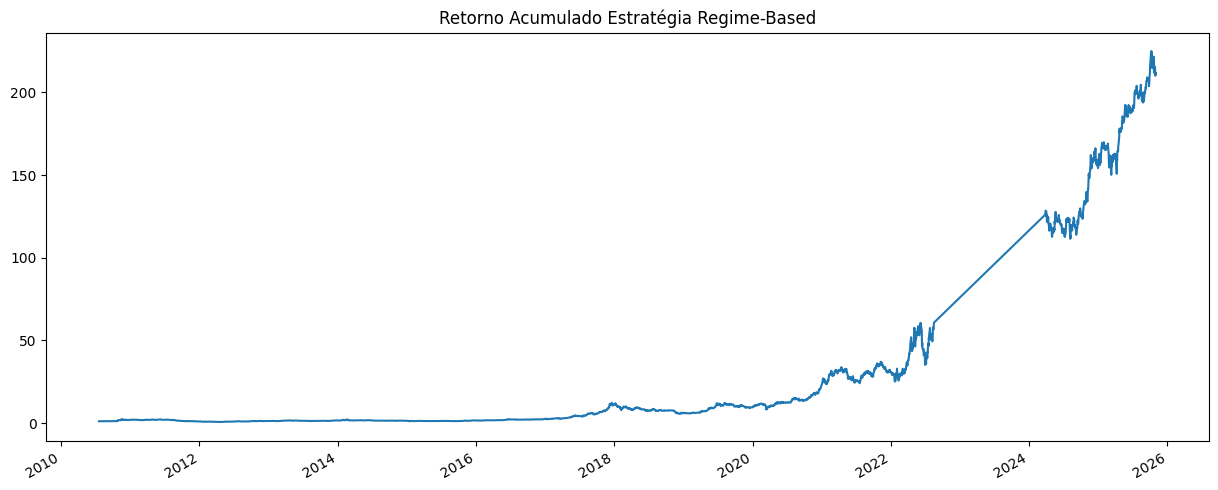

Retorno acumulado: 21050.26%


np.float64(21050.264293291864)

In [56]:
import pandas as pd
import numpy as np

# Função para carregar os dados
def load_data():
    btc = pd.read_csv('BTC_com_ciclos_HALVING.csv', parse_dates=['Data'], index_col='Data')
    xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.', parse_dates=['Data'], index_col='Data')
    ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.', parse_dates=['Data'], index_col='Data')
    macro = pd.read_csv('macro_data.csv', parse_dates=['Date'], index_col='Date')
    return btc, xau, ng, macro

# Alinha tudo por inner join dos índices (Data)
btc, xau, ng, macro = load_data()
df = btc.join([xau['Último'].rename('xau'), ng['Último'].rename('ng')], how='inner')
df = df.join(macro, how='inner')

df = df.sort_index(ascending=True)

# Retornos diários
df['btc_ret'] = df['btc_price'].pct_change()
df['xau_ret'] = df['xau'].pct_change()
df['ng_ret'] = df['ng'].pct_change()

# --- ### MUDANÇA AQUI ### ---
# Alterando o gatilho de P80 (Pânico) para P60 (Medo)
vix_p70 = df['vix'].quantile(0.70) 
df['regime'] = np.where(df['vix'] > vix_p70, 'Risk-Off', 'Risk-On')

# Simulação da estratégia:
weights = {
    'Risk-On': {'btc_ret': 0.5, 'xau_ret': 0.5, 'ng_ret': 0.0},
    'Risk-Off': {'btc_ret': 0.0, 'xau_ret': 0.0, 'ng_ret': 1.0}
}

def strategy_return(row):
    w = weights[row['regime']]
    return sum([row[ret] * weight for ret, weight in w.items()])

df['strat_ret'] = df.apply(strategy_return, axis=1)
df['strat_cum'] = (1 + df['strat_ret'].fillna(0)).cumprod()

# Plotar resultado
import matplotlib.pyplot as plt
df['strat_cum'].plot(figsize=(15,6), title='Retorno Acumulado Estratégia Regime-Based')
plt.show()

def strategy_performance_report(df):
    inicio = df['strat_cum'].first_valid_index()
    fim = df['strat_cum'].last_valid_index()
    valor_final = df.loc[fim, 'strat_cum']
    valor_inicial = df.loc[inicio, 'strat_cum']
    ret_pct = (valor_final - valor_inicial) / valor_inicial * 100
    print(f"Retorno acumulado: {ret_pct:.2f}%")
    return ret_pct

# Coloque depois que df['strat_cum'] já foi calculado!
strategy_performance_report(df)

# Análises adicionais: drawdown, sharpe, rolling correl...


In [57]:

if not pd.api.types.is_datetime64_any_dtype(df.index):
    df.index = pd.to_datetime(df.index)

def annual_return(df, year):
    df_y = df[df.index.year == year]
    if df_y.shape[0] == 0:
        return None
    start = df_y['strat_cum'].iloc[0]
    end = df_y['strat_cum'].iloc[-1]
    ret_pct = (end - start) / start * 100
    print(f"Retorno {year}: {ret_pct:.2f}%")
    return ret_pct

rets = {year: annual_return(df, year) for year in [2023, 2024, 2025]}
print(rets)


Retorno 2024: 23.42%
Retorno 2025: 32.98%
{2023: None, 2024: np.float64(23.42222086918793), 2025: np.float64(32.984355830496064)}


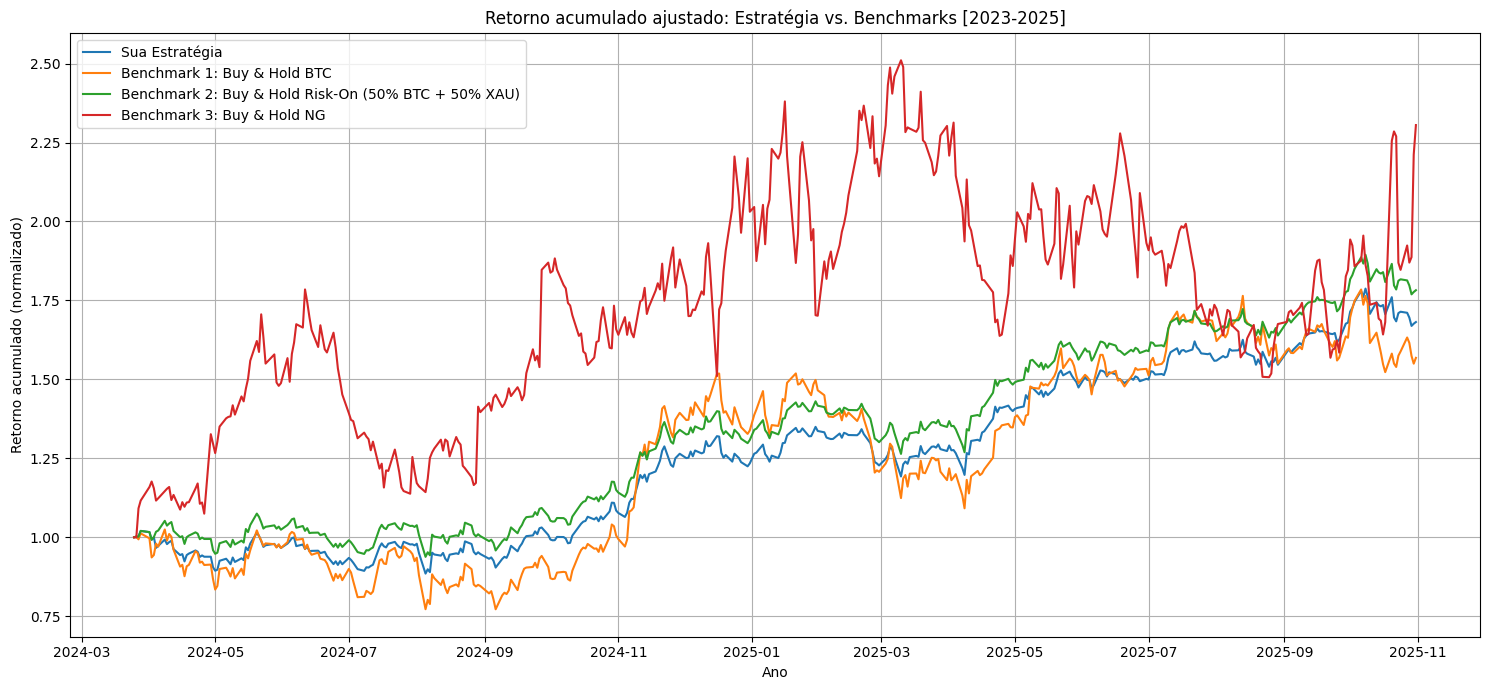

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Filtrar o DataFrame apenas para [2023, 2024, 2025]
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# 2. RECALCULAR strat_cum SÓ NO INTERVALO (isso evita problemas de indexação!)
df_sel['strat_cum_norm'] = (1 + df_sel['strat_ret'].fillna(0)).cumprod()

# 3. RECALCULAR OS BENCHMARKS SÓ NO INTERVALO
btc_cum_sel = (1 + df_sel['btc_ret'].fillna(0)).cumprod()
benchmark_ret_sel = 0.5 * df_sel['btc_ret'] + 0.5 * df_sel['xau_ret']
benchmark_cum_sel = (1 + benchmark_ret_sel.fillna(0)).cumprod()
ng_cum_sel = (1 + df_sel['ng_ret'].fillna(0)).cumprod()

# 4. NORMALIZAR pelo primeiro valor de cada série
start_strat = df_sel['strat_cum_norm'].iloc[0]
start_btc = btc_cum_sel.iloc[0]
start_bench = benchmark_cum_sel.iloc[0]
start_ng = ng_cum_sel.iloc[0]

# 5. PLOT
plt.figure(figsize=(15,7))
plt.plot(df_sel.index, df_sel['strat_cum_norm']/start_strat, label='Sua Estratégia')
plt.plot(df_sel.index, btc_cum_sel/start_btc, label='Benchmark 1: Buy & Hold BTC')
plt.plot(df_sel.index, benchmark_cum_sel/start_bench, label='Benchmark 2: Buy & Hold Risk-On (50% BTC + 50% XAU)')
plt.plot(df_sel.index, ng_cum_sel/start_ng, label='Benchmark 3: Buy & Hold NG')
plt.legend()
plt.title('Retorno acumulado ajustado: Estratégia vs. Benchmarks [2023-2025]')
plt.xlabel('Ano')
plt.ylabel('Retorno acumulado (normalizado)')
plt.grid()
plt.tight_layout()
plt.show()


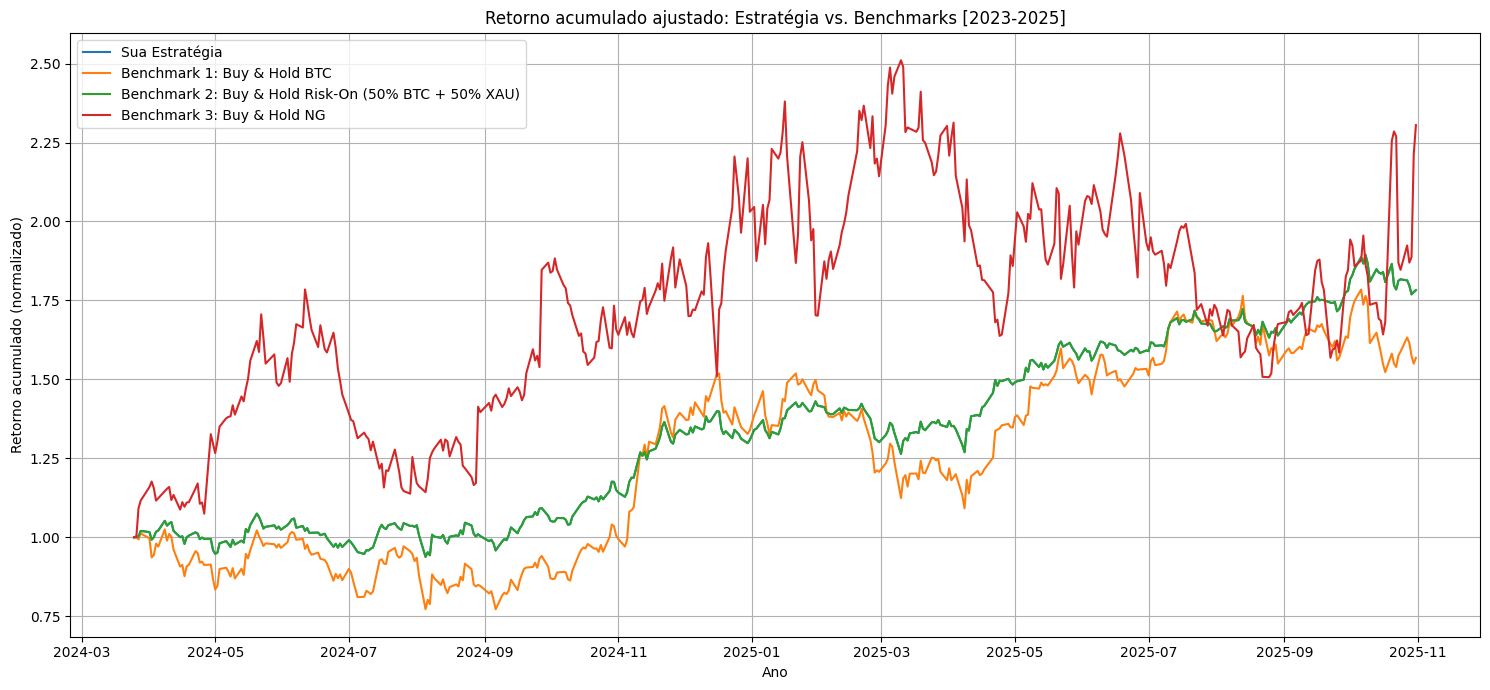

In [53]:
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# --- CORREÇÃO 1: Calcule a estratégia como uma Série separada ---
# Em vez de df_sel['strat_cum_norm'] = ...
strat_cum_sel = (1 + df_sel['strat_ret'].fillna(0)).cumprod() 
# -----------------------------------------------------------------

btc_cum_sel = (1 + df_sel['btc_ret'].fillna(0)).cumprod()
benchmark_ret_sel = 0.5 * df_sel['btc_ret'] + 0.5 * df_sel['xau_ret']
benchmark_cum_sel = (1 + benchmark_ret_sel.fillna(0)).cumprod()
ng_cum_sel = (1 + df_sel['ng_ret'].fillna(0)).cumprod()

# --- CORREÇÃO 2: Adicione sua estratégia à interseção ---
common_dates = df_sel.index.intersection(strat_cum_sel.index) \
                           .intersection(btc_cum_sel.index) \
                           .intersection(benchmark_cum_sel.index) \
                           .intersection(ng_cum_sel.index)
# ----------------------------------------------------------

plt.figure(figsize=(15,7))

# --- CORREÇÃO 3: Plote a nova Série da estratégia ---
plt.plot(common_dates, strat_cum_sel.loc[common_dates]/strat_cum_sel.loc[common_dates[0]], label='Sua Estratégia')
# ----------------------------------------------------

plt.plot(common_dates, btc_cum_sel.loc[common_dates]/btc_cum_sel.loc[common_dates[0]], label='Benchmark 1: Buy & Hold BTC')
plt.plot(common_dates, benchmark_cum_sel.loc[common_dates]/benchmark_cum_sel.loc[common_dates[0]], label='Benchmark 2: Buy & Hold Risk-On (50% BTC + 50% XAU)')
plt.plot(common_dates, ng_cum_sel.loc[common_dates]/ng_cum_sel.loc[common_dates[0]], label='Benchmark 3: Buy & Hold NG')
plt.legend()
plt.title('Retorno acumulado ajustado: Estratégia vs. Benchmarks [2023-2025]')
plt.xlabel('Ano')
plt.ylabel('Retorno acumulado (normalizado)')
plt.grid()
plt.tight_layout()
plt.show()

NaNs na estratégia: 0
NaNs no BTC: 0
NaNs no NG: 0
NaNs no benchmark: 0

Valores da estratégia (primeiros 5):
2024-03-25   2.08
2024-03-26   2.08
2024-03-27   2.08
2024-03-28   2.12
2024-04-01   2.11
Name: strat_ret, dtype: float64

Valores da estratégia (últimos 5):
2025-10-27   3.77
2025-10-28   3.73
2025-10-29   3.67
2025-10-30   3.69
2025-10-31   3.70
Name: strat_ret, dtype: float64


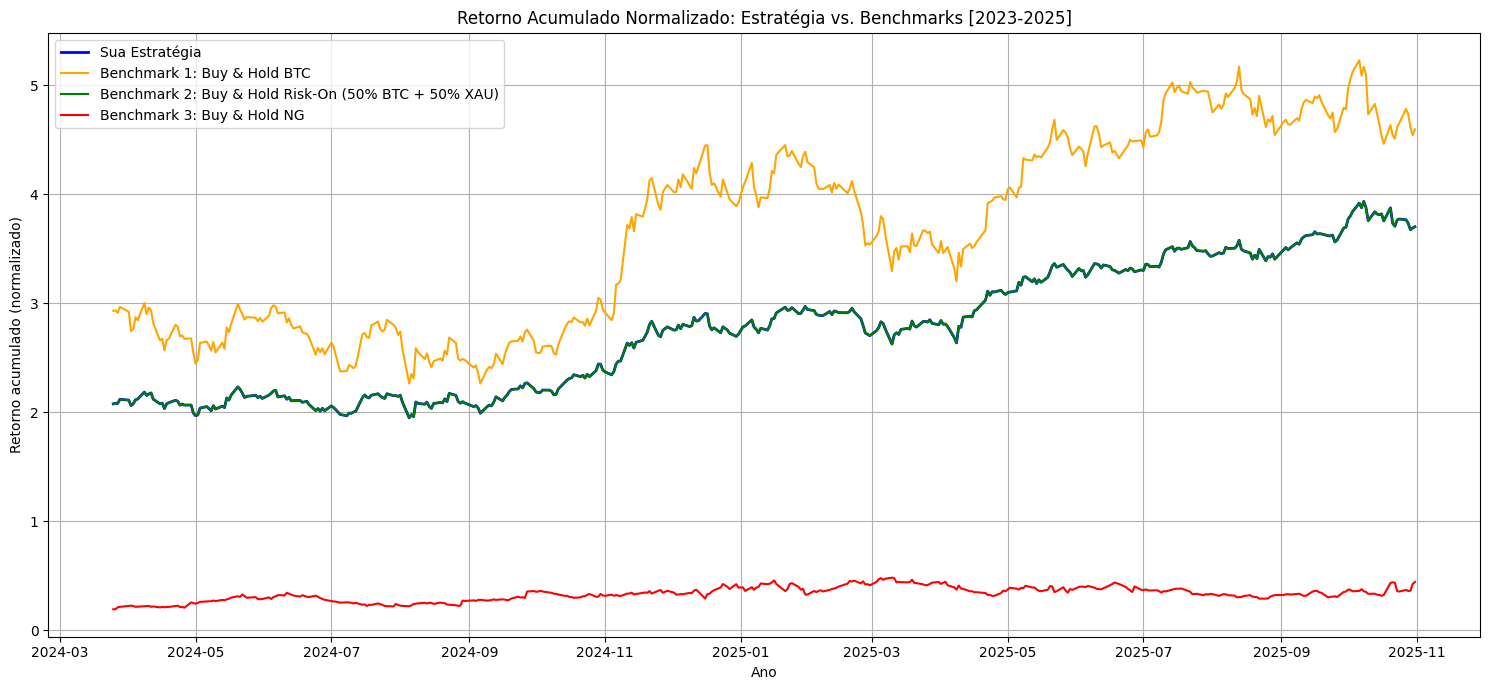

In [54]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Selecionar o período ---
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# --- 2. Criar as séries de RETORNO para o período ---
strat_ret_sel = df_sel['strat_ret'].copy()
btc_ret_sel = df_sel['btc_ret'].copy()
ng_ret_sel = df_sel['ng_ret'].copy()
bench_ret_sel = (0.5 * df_sel['btc_ret'] + 0.5 * df_sel['xau_ret']).copy()

# --- 3. CORREÇÃO: Limpar TODOS os NaNs, não apenas o primeiro ---
strat_ret_sel = strat_ret_sel.fillna(0)
btc_ret_sel = btc_ret_sel.fillna(0)
ng_ret_sel = ng_ret_sel.fillna(0)
bench_ret_sel = bench_ret_sel.fillna(0)

# --- 4. DIAGNÓSTICO: Verificar se ainda há NaNs ---
print("NaNs na estratégia:", strat_ret_sel.isna().sum())
print("NaNs no BTC:", btc_ret_sel.isna().sum())
print("NaNs no NG:", ng_ret_sel.isna().sum())
print("NaNs no benchmark:", bench_ret_sel.isna().sum())

# --- 5. Calcular o retorno acumulado ---
strat_cum_norm = (1 + strat_ret_sel).cumprod()
btc_cum_norm = (1 + btc_ret_sel).cumprod()
bench_cum_norm = (1 + bench_ret_sel).cumprod()
ng_cum_norm = (1 + ng_ret_sel).cumprod()

# --- 6. DIAGNÓSTICO FINAL: Verificar os valores acumulados ---
print("\nValores da estratégia (primeiros 5):")
print(strat_cum_norm.head())
print("\nValores da estratégia (últimos 5):")
print(strat_cum_norm.tail())

# --- 7. Plotar com verificação ---
plt.figure(figsize=(15,7))
plt.plot(strat_cum_norm.index, strat_cum_norm.values, label='Sua Estratégia', linewidth=2, color='blue')
plt.plot(btc_cum_norm.index, btc_cum_norm.values, label='Benchmark 1: Buy & Hold BTC', color='orange')
plt.plot(bench_cum_norm.index, bench_cum_norm.values, label='Benchmark 2: Buy & Hold Risk-On (50% BTC + 50% XAU)', color='green')
plt.plot(ng_cum_norm.index, ng_cum_norm.values, label='Benchmark 3: Buy & Hold NG', color='red')

plt.legend()
plt.title('Retorno Acumulado Normalizado: Estratégia vs. Benchmarks [2023-2025]')
plt.xlabel('Ano')
plt.ylabel('Retorno acumulado (normalizado)')
plt.grid()
plt.tight_layout()
plt.show()


MÉTRICAS DE PERFORMANCE [2023-2025]

📊 SUA ESTRATÉGIA:
   Retorno Total: 249.15%
   Sharpe Ratio: 1.155
   Maximum Drawdown: -13.25%

🟠 BENCHMARK 1 (Buy & Hold BTC):
   Retorno Total: 359.42%
   Sharpe Ratio: 0.996
   Maximum Drawdown: -28.11%

🟢 BENCHMARK 2 (50% BTC + 50% XAU):
   Retorno Total: 270.07%
   Sharpe Ratio: 1.197
   Maximum Drawdown: -12.74%

🔴 BENCHMARK 3 (Buy & Hold NG):
   Retorno Total: -55.71%
   Sharpe Ratio: 0.325
   Maximum Drawdown: -39.97%


TABELA COMPARATIVA:
       Estratégia  Retorno Total (%)  Sharpe Ratio  Max Drawdown (%)
   Sua Estratégia             249.15          1.16            -13.25
              BTC             359.42          1.00            -28.11
50% BTC + 50% XAU             270.07          1.20            -12.74
               NG             -55.71          0.33            -39.97


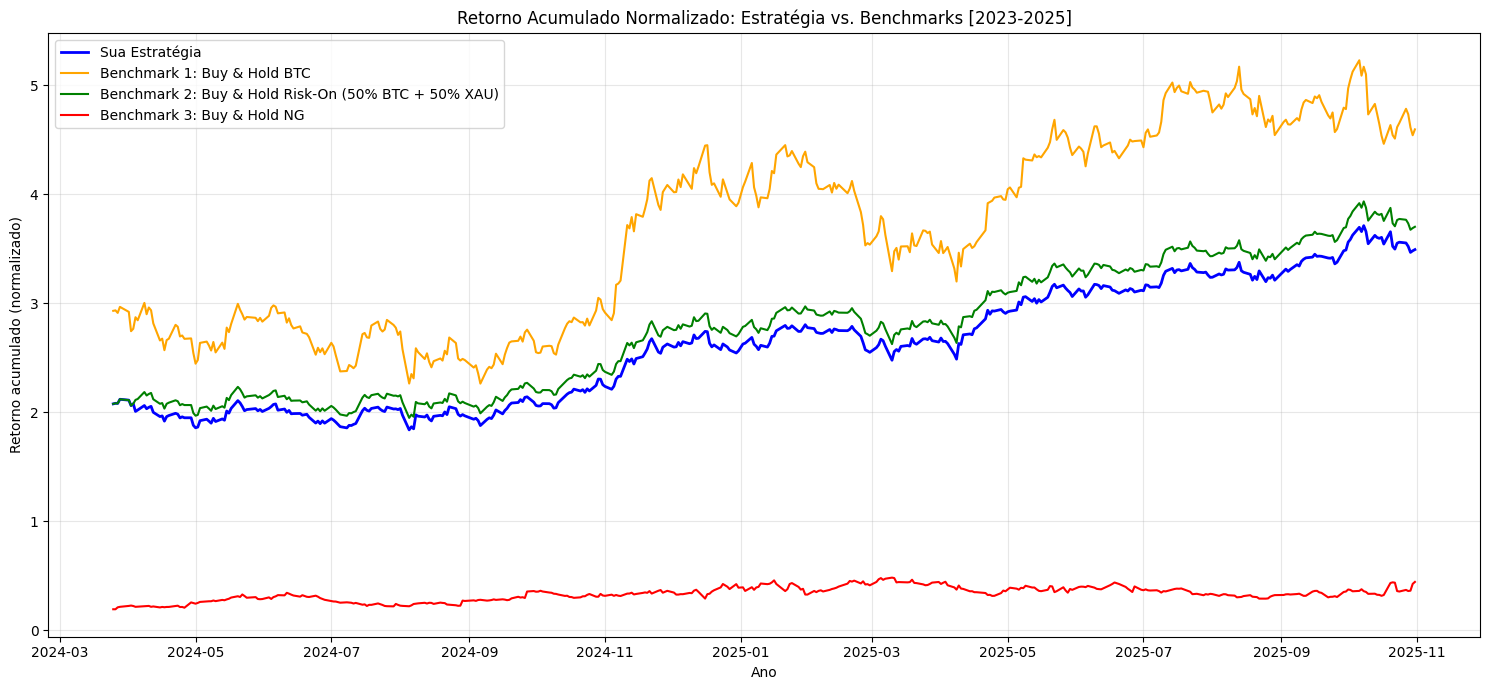

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Selecionar o período ---
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# --- 2. Criar as séries de RETORNO para o período ---
strat_ret_sel = df_sel['strat_ret'].fillna(0)
btc_ret_sel = df_sel['btc_ret'].fillna(0)
ng_ret_sel = df_sel['ng_ret'].fillna(0)
bench_ret_sel = (0.5 * df_sel['btc_ret'] + 0.5 * df_sel['xau_ret']).fillna(0)

# --- 3. Calcular o retorno acumulado ---
strat_cum_norm = (1 + strat_ret_sel).cumprod()
btc_cum_norm = (1 + btc_ret_sel).cumprod()
bench_cum_norm = (1 + bench_ret_sel).cumprod()
ng_cum_norm = (1 + ng_ret_sel).cumprod()

# --- 4. Função para calcular Sharpe Ratio ---
def sharpe_ratio(returns, periods_per_year=252):
    """
    Calcula o Sharpe Ratio anualizado
    periods_per_year: 252 para dias de negociação
    """
    mean_return = returns.mean()
    std_return = returns.std()
    if std_return == 0:
        return 0
    sharpe = np.sqrt(periods_per_year) * (mean_return / std_return)
    return sharpe

# --- 5. Função para calcular Maximum Drawdown ---
def max_drawdown(cum_returns):
    """
    Calcula o Maximum Drawdown a partir de retornos acumulados
    """
    # Calcular o máximo acumulado (pico histórico)
    running_max = np.maximum.accumulate(cum_returns)
    
    # Calcular o drawdown em cada ponto
    drawdown = (cum_returns - running_max) / running_max
    
    # Retornar o drawdown máximo (mais negativo)
    max_dd = drawdown.min()
    
    return max_dd

# --- 6. Calcular métricas para cada estratégia ---
print("="*70)
print("MÉTRICAS DE PERFORMANCE [2023-2025]")
print("="*70)

# Sua Estratégia
sharpe_strat = sharpe_ratio(strat_ret_sel)
mdd_strat = max_drawdown(strat_cum_norm.values)
retorno_total_strat = (strat_cum_norm.iloc[-1] - 1) * 100

print(f"\n📊 SUA ESTRATÉGIA:")
print(f"   Retorno Total: {retorno_total_strat:.2f}%")
print(f"   Sharpe Ratio: {sharpe_strat:.3f}")
print(f"   Maximum Drawdown: {mdd_strat*100:.2f}%")

# Benchmark 1: BTC
sharpe_btc = sharpe_ratio(btc_ret_sel)
mdd_btc = max_drawdown(btc_cum_norm.values)
retorno_total_btc = (btc_cum_norm.iloc[-1] - 1) * 100

print(f"\n🟠 BENCHMARK 1 (Buy & Hold BTC):")
print(f"   Retorno Total: {retorno_total_btc:.2f}%")
print(f"   Sharpe Ratio: {sharpe_btc:.3f}")
print(f"   Maximum Drawdown: {mdd_btc*100:.2f}%")

# Benchmark 2: 50% BTC + 50% XAU
sharpe_bench = sharpe_ratio(bench_ret_sel)
mdd_bench = max_drawdown(bench_cum_norm.values)
retorno_total_bench = (bench_cum_norm.iloc[-1] - 1) * 100

print(f"\n🟢 BENCHMARK 2 (50% BTC + 50% XAU):")
print(f"   Retorno Total: {retorno_total_bench:.2f}%")
print(f"   Sharpe Ratio: {sharpe_bench:.3f}")
print(f"   Maximum Drawdown: {mdd_bench*100:.2f}%")

# Benchmark 3: NG
sharpe_ng = sharpe_ratio(ng_ret_sel)
mdd_ng = max_drawdown(ng_cum_norm.values)
retorno_total_ng = (ng_cum_norm.iloc[-1] - 1) * 100

print(f"\n🔴 BENCHMARK 3 (Buy & Hold NG):")
print(f"   Retorno Total: {retorno_total_ng:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ng:.3f}")
print(f"   Maximum Drawdown: {mdd_ng*100:.2f}%")

print("\n" + "="*70)

# --- 7. Criar tabela comparativa ---
metricas_df = pd.DataFrame({
    'Estratégia': ['Sua Estratégia', 'BTC', '50% BTC + 50% XAU', 'NG'],
    'Retorno Total (%)': [retorno_total_strat, retorno_total_btc, retorno_total_bench, retorno_total_ng],
    'Sharpe Ratio': [sharpe_strat, sharpe_btc, sharpe_bench, sharpe_ng],
    'Max Drawdown (%)': [mdd_strat*100, mdd_btc*100, mdd_bench*100, mdd_ng*100]
})

print("\nTABELA COMPARATIVA:")
print(metricas_df.to_string(index=False))

# --- 8. Plotar gráfico ---
plt.figure(figsize=(15,7))
plt.plot(strat_cum_norm.index, strat_cum_norm.values, label='Sua Estratégia', linewidth=2, color='blue')
plt.plot(btc_cum_norm.index, btc_cum_norm.values, label='Benchmark 1: Buy & Hold BTC', color='orange')
plt.plot(bench_cum_norm.index, bench_cum_norm.values, label='Benchmark 2: Buy & Hold Risk-On (50% BTC + 50% XAU)', color='green')
plt.plot(ng_cum_norm.index, ng_cum_norm.values, label='Benchmark 3: Buy & Hold NG', color='red')

plt.legend(loc='best')
plt.title('Retorno Acumulado Normalizado: Estratégia vs. Benchmarks [2023-2025]')
plt.xlabel('Ano')
plt.ylabel('Retorno acumulado (normalizado)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Selecionar o período [2023-2025] ---
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# --- 2. Criar as séries de RETORNO ---
strat_ret = df_sel['strat_ret'].fillna(0)
btc_ret = df_sel['btc_ret'].fillna(0)
xau_ret = df_sel['xau_ret'].fillna(0)
ng_ret = df_sel['ng_ret'].fillna(0)

# --- 3. Calcular retornos acumulados ---
strat_cum = (1 + strat_ret).cumprod()
btc_cum = (1 + btc_ret).cumprod()
xau_cum = (1 + xau_ret).cumprod()
ng_cum = (1 + ng_ret).cumprod()

# --- 4. FUNÇÕES DE MÉTRICAS ---
def sharpe_ratio(returns, periods_per_year=252):
    """Sharpe Ratio anualizado"""
    mean_ret = returns.mean()
    std_ret = returns.std()
    if std_ret == 0 or np.isnan(std_ret):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / std_ret)

def sortino_ratio(returns, periods_per_year=252):
    """Sortino Ratio - considera apenas volatilidade negativa"""
    mean_ret = returns.mean()
    downside_ret = returns[returns < 0]
    downside_std = downside_ret.std()
    if downside_std == 0 or np.isnan(downside_std):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / downside_std)

def max_drawdown(cum_returns):
    """Maximum Drawdown"""
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

def calmar_ratio(returns, cum_returns, periods_per_year=252):
    """Calmar Ratio - retorno anualizado / max drawdown absoluto"""
    total_return = cum_returns.iloc[-1] - 1
    years = len(returns) / periods_per_year
    annualized_return = (1 + total_return) ** (1/years) - 1
    mdd = abs(max_drawdown(cum_returns.values))
    if mdd == 0:
        return 0
    return annualized_return / mdd

def win_rate(returns):
    """Taxa de dias positivos"""
    return (returns > 0).sum() / len(returns) * 100

def volatility(returns, periods_per_year=252):
    """Volatilidade anualizada"""
    return returns.std() * np.sqrt(periods_per_year) * 100

# --- 5. CALCULAR TODAS AS MÉTRICAS ---
estrategias = {
    'Sua Estratégia': (strat_ret, strat_cum),
    'Buy & Hold BTC': (btc_ret, btc_cum),
    'Buy & Hold Ouro (XAU)': (xau_ret, xau_cum),
    'Buy & Hold NG': (ng_ret, ng_cum)
}

resultados = []

for nome, (ret, cum) in estrategias.items():
    retorno_total = (cum.iloc[-1] - 1) * 100
    retorno_anualizado = ((1 + retorno_total/100) ** (252/len(ret)) - 1) * 100
    sharpe = sharpe_ratio(ret)
    sortino = sortino_ratio(ret)
    mdd = max_drawdown(cum.values) * 100
    calmar = calmar_ratio(ret, cum)
    vol = volatility(ret)
    taxa_vitoria = win_rate(ret)
    
    resultados.append({
        'Estratégia': nome,
        'Retorno Total (%)': retorno_total,
        'Retorno Anualizado (%)': retorno_anualizado,
        'Volatilidade (%)': vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Max Drawdown (%)': mdd,
        'Taxa de Vitória (%)': taxa_vitoria
    })

# --- 6. CRIAR DATAFRAME COMPARATIVO ---
df_comparacao = pd.DataFrame(resultados)

# --- 7. IMPRIMIR RESULTADOS ---
print("=" * 100)
print("COMPARAÇÃO COMPLETA: SUA ESTRATÉGIA vs. BUY & HOLD [2023-2025]")
print("=" * 100)
print()

# Formatar melhor a tabela
pd.options.display.float_format = '{:.2f}'.format
print(df_comparacao.to_string(index=False))
print()
print("=" * 100)

# --- 8. ANÁLISE DE RANKING ---
print("\n📊 RANKING POR MÉTRICA:")
print("-" * 100)

metricas_ranking = [
    ('Retorno Total (%)', False),
    ('Sharpe Ratio', False),
    ('Sortino Ratio', False),
    ('Calmar Ratio', False),
    ('Max Drawdown (%)', True),  # True = menor é melhor
    ('Volatilidade (%)', True)
]

for metrica, menor_melhor in metricas_ranking:
    df_sorted = df_comparacao.sort_values(metrica, ascending=menor_melhor)
    print(f"\n🏆 {metrica}:")
    for i, row in enumerate(df_sorted.itertuples(), 1):
        emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
        valor = getattr(row, metrica.replace(' ', '_').replace('(', '').replace(')', '').replace('%', ''))
        print(f"   {emoji} {i}º - {row.Estratégia}: {valor:.2f}")

# --- 9. GRÁFICO DE RETORNOS ACUMULADOS ---
plt.figure(figsize=(16, 8))
plt.plot(strat_cum.index, strat_cum.values, label='Sua Estratégia (Regime-Based)', 
         linewidth=2.5, color='blue')
plt.plot(btc_cum.index, btc_cum.values, label='Buy & Hold BTC', 
         linewidth=2, color='orange', alpha=0.8)
plt.plot(xau_cum.index, xau_cum.values, label='Buy & Hold Ouro (XAU)', 
         linewidth=2, color='gold', alpha=0.8)
plt.plot(ng_cum.index, ng_cum.values, label='Buy & Hold Natural Gas (NG)', 
         linewidth=2, color='red', alpha=0.8)

plt.legend(loc='best', fontsize=11)
plt.title('Comparação de Retornos Acumulados [2023-2025]', fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Retorno Acumulado (Normalizado)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 10. GRÁFICO DE MÉTRICAS COMPARATIVAS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparação de Métricas de Performance [2023-2025]', 
             fontsize=16, fontweight='bold')

cores = ['blue', 'orange', 'gold', 'red']

# Sharpe Ratio
ax1 = axes[0, 0]
sharpes = df_comparacao['Sharpe Ratio'].values
ax1.bar(range(4), sharpes, color=cores)
ax1.set_xticks(range(4))
ax1.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio (Maior = Melhor)')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# Sortino Ratio
ax2 = axes[0, 1]
sortinos = df_comparacao['Sortino Ratio'].values
ax2.bar(range(4), sortinos, color=cores)
ax2.set_xticks(range(4))
ax2.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax2.set_ylabel('Sortino Ratio')
ax2.set_title('Sortino Ratio (Maior = Melhor)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# Calmar Ratio
ax3 = axes[0, 2]
calmars = df_comparacao['Calmar Ratio'].values
ax3.bar(range(4), calmars, color=cores)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax3.set_ylabel('Calmar Ratio')
ax3.set_title('Calmar Ratio (Maior = Melhor)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# Maximum Drawdown
ax4 = axes[1, 0]
mdds = df_comparacao['Max Drawdown (%)'].values
ax4.bar(range(4), mdds, color=cores)
ax4.set_xticks(range(4))
ax4.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax4.set_ylabel('Max Drawdown (%)')
ax4.set_title('Max Drawdown (Menor = Melhor)')
ax4.grid(True, alpha=0.3)

# Volatilidade
ax5 = axes[1, 1]
vols = df_comparacao['Volatilidade (%)'].values
ax5.bar(range(4), vols, color=cores)
ax5.set_xticks(range(4))
ax5.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax5.set_ylabel('Volatilidade Anualizada (%)')
ax5.set_title('Volatilidade (Menor = Melhor)')
ax5.grid(True, alpha=0.3)

# Retorno Total
ax6 = axes[1, 2]
rets = df_comparacao['Retorno Total (%)'].values
ax6.bar(range(4), rets, color=cores)
ax6.set_xticks(range(4))
ax6.set_xticklabels(['Estratégia', 'BTC', 'Ouro', 'NG'], rotation=45, ha='right')
ax6.set_ylabel('Retorno Total (%)')
ax6.set_title('Retorno Total (Maior = Melhor)')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 11. ANÁLISE CONCLUSIVA ---
print("\n" + "=" * 100)
print("💡 ANÁLISE CONCLUSIVA:")
print("=" * 100)

melhor_sharpe = df_comparacao.loc[df_comparacao['Sharpe Ratio'].idxmax(), 'Estratégia']
melhor_retorno = df_comparacao.loc[df_comparacao['Retorno Total (%)'].idxmax(), 'Estratégia']
menor_dd = df_comparacao.loc[df_comparacao['Max Drawdown (%)'].idxmax(), 'Estratégia']
menor_vol = df_comparacao.loc[df_comparacao['Volatilidade (%)'].idxmin(), 'Estratégia']

print(f"\n✅ Melhor Sharpe Ratio (retorno ajustado ao risco): {melhor_sharpe}")
print(f"✅ Maior Retorno Total: {melhor_retorno}")
print(f"✅ Menor Drawdown (mais seguro): {menor_dd}")
print(f"✅ Menor Volatilidade (mais estável): {menor_vol}")

print("\n" + "=" * 100)


COMPARAÇÃO COMPLETA: SUA ESTRATÉGIA vs. BUY & HOLD [2023-2025]

           Estratégia  Retorno Total (%)  Retorno Anualizado (%)  Volatilidade (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)  Taxa de Vitória (%)
       Sua Estratégia             270.07                  124.83             88.30          1.20           6.85          9.80            -12.74                52.83
       Buy & Hold BTC             359.42                  157.05            158.67          1.00           5.68          5.59            -28.11                51.11
Buy & Hold Ouro (XAU)             125.41                   65.41             25.01          2.13           4.25          6.69             -9.78                56.76
        Buy & Hold NG             -55.71                  -39.60            103.30          0.33           0.34         -0.99            -39.97                50.86


📊 RANKING POR MÉTRICA:
--------------------------------------------------------------------------------------

AttributeError: 'Pandas' object has no attribute 'Retorno_Total_'

# Testar entrar vendido em NG

C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\4217899153.py:9: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.',
C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\4217899153.py:11: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.',



📊 Gatilho VIX P70 = 86.37
Dias em Risk-On: 2415
Dias em Risk-Off: 1035

ESTRATÉGIA: 50% BTC + 50% Ouro (Risk-On) | 100% SHORT NG (Risk-Off)

✅ Retorno Total: 1756.62%
✅ Sharpe Ratio: 0.632
✅ Maximum Drawdown: -75.61%
✅ Volatilidade Anualizada: 52.72%
✅ Taxa de Vitória: 52.72%



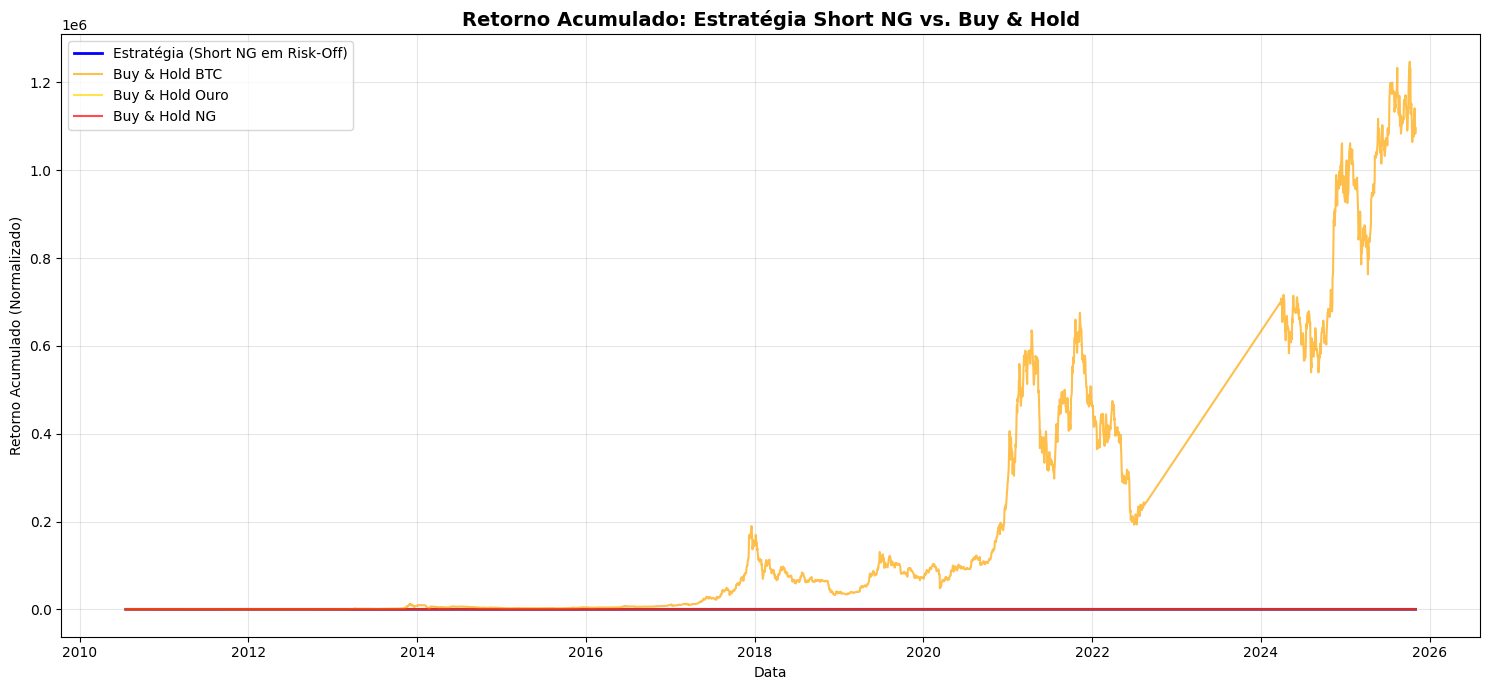


📈 ANÁLISE POR REGIME:
--------------------------------------------------------------------------------
Risk-On  - Retorno: 10097.75% | Dias: 2415
Risk-Off - Retorno: -81.79% | Dias: 1035

Retorno médio diário do SHORT NG em Risk-Off: -0.1175%

✅ Backtest concluído com sucesso!


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Função para carregar os dados
def load_data():
    btc = pd.read_csv('BTC_com_ciclos_HALVING.csv', parse_dates=['Data'], index_col='Data')
    xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.', 
                      parse_dates=['Data'], index_col='Data')
    ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.', 
                     parse_dates=['Data'], index_col='Data')
    macro = pd.read_csv('macro_data.csv', parse_dates=['Date'], index_col='Date')
    return btc, xau, ng, macro


# Alinha tudo por inner join dos índices
try:
    btc, xau, ng, macro = load_data()
    
    # Join dos dados de preços
    df = btc.join([xau['Último'].rename('xau'), ng['Último'].rename('ng')], how='inner')
    df = df.join(macro, how='inner')

    # GARANTIR ORDEM CRONOLÓGICA
    df = df.sort_index(ascending=True) 

    # Retornos diários
    df['btc_ret'] = df['btc_price'].pct_change()
    df['xau_ret'] = df['xau'].pct_change()
    df['ng_ret'] = df['ng'].pct_change()

    # --- GATILHO: VIX P70 ---
    vix_p70 = df['vix'].quantile(0.70) 
    df['regime'] = np.where(df['vix'] > vix_p70, 'Risk-Off', 'Risk-On')
    
    print(f"\n📊 Gatilho VIX P70 = {vix_p70:.2f}")
    print(f"Dias em Risk-On: {(df['regime'] == 'Risk-On').sum()}")
    print(f"Dias em Risk-Off: {(df['regime'] == 'Risk-Off').sum()}")

    # --- ESTRATÉGIA: SHORT NG EM RISK-OFF ---
    # Risk-On: 50% BTC + 50% Ouro
    # Risk-Off: 100% SHORT Natural Gas (retorno negativo de NG)
    weights = {
        'Risk-On': {'btc_ret': 0.5, 'xau_ret': 0.5, 'ng_ret': 0.0},
        'Risk-Off': {'btc_ret': 0.0, 'xau_ret': 0.0, 'ng_ret': -1.0}  # SHORT NG
    }

    def strategy_return(row):
        """Calcula o retorno da estratégia baseado no regime"""
        w = weights[row['regime']]
        ret = 0
        for asset_ret, weight in w.items():
            if pd.notna(row[asset_ret]) and weight != 0:
                ret += row[asset_ret] * weight
        return ret

    df['strat_ret'] = df.apply(strategy_return, axis=1)
    
    # Retorno acumulado
    df['strat_cum'] = (1 + df['strat_ret'].fillna(0)).cumprod()

    # --- ANÁLISE DE PERFORMANCE ---
    print("\n" + "="*80)
    print("ESTRATÉGIA: 50% BTC + 50% Ouro (Risk-On) | 100% SHORT NG (Risk-Off)")
    print("="*80)
    
    # Retorno total
    retorno_total = (df['strat_cum'].iloc[-1] - 1) * 100
    print(f"\n✅ Retorno Total: {retorno_total:.2f}%")
    
    # Sharpe Ratio
    sharpe = (df['strat_ret'].mean() / df['strat_ret'].std()) * np.sqrt(252)
    print(f"✅ Sharpe Ratio: {sharpe:.3f}")
    
    # Maximum Drawdown
    running_max = np.maximum.accumulate(df['strat_cum'].values)
    drawdown = (df['strat_cum'].values - running_max) / running_max
    max_dd = drawdown.min() * 100
    print(f"✅ Maximum Drawdown: {max_dd:.2f}%")
    
    # Volatilidade
    vol = df['strat_ret'].std() * np.sqrt(252) * 100
    print(f"✅ Volatilidade Anualizada: {vol:.2f}%")
    
    # Taxa de vitória
    win_rate = (df['strat_ret'] > 0).sum() / len(df['strat_ret']) * 100
    print(f"✅ Taxa de Vitória: {win_rate:.2f}%")
    
    print("\n" + "="*80)

    # --- GRÁFICO DE RETORNO ACUMULADO ---
    plt.figure(figsize=(15, 7))
    plt.plot(df.index, df['strat_cum'], label='Estratégia (Short NG em Risk-Off)', 
             linewidth=2, color='blue')
    
    # Comparação com Buy & Hold
    btc_cum = (1 + df['btc_ret'].fillna(0)).cumprod()
    xau_cum = (1 + df['xau_ret'].fillna(0)).cumprod()
    ng_cum = (1 + df['ng_ret'].fillna(0)).cumprod()
    
    plt.plot(df.index, btc_cum, label='Buy & Hold BTC', 
             linewidth=1.5, color='orange', alpha=0.7)
    plt.plot(df.index, xau_cum, label='Buy & Hold Ouro', 
             linewidth=1.5, color='gold', alpha=0.7)
    plt.plot(df.index, ng_cum, label='Buy & Hold NG', 
             linewidth=1.5, color='red', alpha=0.7)
    
    plt.legend(loc='best')
    plt.title('Retorno Acumulado: Estratégia Short NG vs. Buy & Hold', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Data')
    plt.ylabel('Retorno Acumulado (Normalizado)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- ANÁLISE DOS REGIMES ---
    print("\n📈 ANÁLISE POR REGIME:")
    print("-"*80)
    
    # Performance em Risk-On
    risk_on_data = df[df['regime'] == 'Risk-On']
    risk_on_ret = (risk_on_data['strat_ret'].fillna(0) + 1).prod() - 1
    print(f"Risk-On  - Retorno: {risk_on_ret*100:.2f}% | Dias: {len(risk_on_data)}")
    
    # Performance em Risk-Off
    risk_off_data = df[df['regime'] == 'Risk-Off']
    risk_off_ret = (risk_off_data['strat_ret'].fillna(0) + 1).prod() - 1
    print(f"Risk-Off - Retorno: {risk_off_ret*100:.2f}% | Dias: {len(risk_off_data)}")
    
    # Performance do SHORT NG em Risk-Off
    ng_short_ret = (risk_off_data['ng_ret'].fillna(0) * -1).mean()
    print(f"\nRetorno médio diário do SHORT NG em Risk-Off: {ng_short_ret*100:.4f}%")
    
    print("\n" + "="*80)
    print("✅ Backtest concluído com sucesso!")
    print("="*80)

except FileNotFoundError as e:
    print(f"\n❌ ERRO: Arquivo não encontrado - {e}")
    print("\nVerifique se os arquivos CSV estão no diretório correto:")
    print("  - BTC_com_ciclos_HALVING.csv")
    print("  - XAU-USD.csv")
    print("  - Gas Natural Futures.csv")
    print("  - macro_data.csv")
    
except KeyError as e:
    print(f"\n❌ ERRO: Coluna não encontrada - {e}")
    print("\nVerifique se os nomes das colunas estão corretos:")
    print("  - BTC: 'Data', 'btc_price'")
    print("  - XAU: 'Data', 'Último'")
    print("  - NG: 'Data', 'Último'")
    print("  - Macro: 'Date', 'vix'")
    
except Exception as e:
    print(f"\n❌ ERRO inesperado: {e}")
    import traceback
    traceback.print_exc()


In [64]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Selecionar o período [2023-2025] ---
anos = [2023, 2024, 2025]
df_sel = df[df.index.year.isin(anos)].copy()

# --- 2. Criar as séries de RETORNO ---
strat_ret = df_sel['strat_ret'].fillna(0)
btc_ret = df_sel['btc_ret'].fillna(0)
xau_ret = df_sel['xau_ret'].fillna(0)
ng_ret = df_sel['ng_ret'].fillna(0)

# Criar série de SHORT NG (retorno invertido)
ng_short_ret = -ng_ret  # Retorno de posição vendida em NG

# --- 3. Calcular retornos acumulados ---
strat_cum = (1 + strat_ret).cumprod()
btc_cum = (1 + btc_ret).cumprod()
xau_cum = (1 + xau_ret).cumprod()
ng_cum = (1 + ng_ret).cumprod()
ng_short_cum = (1 + ng_short_ret).cumprod()  # Acumulado do short

# --- 4. FUNÇÕES DE MÉTRICAS ---
def sharpe_ratio(returns, periods_per_year=252):
    """Sharpe Ratio anualizado"""
    mean_ret = returns.mean()
    std_ret = returns.std()
    if std_ret == 0 or np.isnan(std_ret):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / std_ret)

def sortino_ratio(returns, periods_per_year=252):
    """Sortino Ratio - considera apenas volatilidade negativa"""
    mean_ret = returns.mean()
    downside_ret = returns[returns < 0]
    downside_std = downside_ret.std()
    if downside_std == 0 or np.isnan(downside_std):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / downside_std)

def max_drawdown(cum_returns):
    """Maximum Drawdown"""
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

def calmar_ratio(returns, cum_returns, periods_per_year=252):
    """Calmar Ratio - retorno anualizado / max drawdown absoluto"""
    total_return = cum_returns.iloc[-1] - 1
    years = len(returns) / periods_per_year
    annualized_return = (1 + total_return) ** (1/years) - 1
    mdd = abs(max_drawdown(cum_returns.values))
    if mdd == 0:
        return 0
    return annualized_return / mdd

def win_rate(returns):
    """Taxa de dias positivos"""
    return (returns > 0).sum() / len(returns) * 100

def volatility(returns, periods_per_year=252):
    """Volatilidade anualizada"""
    return returns.std() * np.sqrt(periods_per_year) * 100

# --- 5. CALCULAR TODAS AS MÉTRICAS ---
estrategias = {
    'Estratégia Short NG': (strat_ret, strat_cum),
    'Buy & Hold BTC': (btc_ret, btc_cum),
    'Buy & Hold Ouro (XAU)': (xau_ret, xau_cum),
    'Buy & Hold NG': (ng_ret, ng_cum),
    'SHORT NG (100%)': (ng_short_ret, ng_short_cum)
}

resultados = []

for nome, (ret, cum) in estrategias.items():
    retorno_total = (cum.iloc[-1] - 1) * 100
    retorno_anualizado = ((1 + retorno_total/100) ** (252/len(ret)) - 1) * 100
    sharpe = sharpe_ratio(ret)
    sortino = sortino_ratio(ret)
    mdd = max_drawdown(cum.values) * 100
    calmar = calmar_ratio(ret, cum)
    vol = volatility(ret)
    taxa_vitoria = win_rate(ret)
    
    resultados.append({
        'Estratégia': nome,
        'Retorno Total (%)': retorno_total,
        'Retorno Anualizado (%)': retorno_anualizado,
        'Volatilidade (%)': vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Max Drawdown (%)': mdd,
        'Taxa de Vitória (%)': taxa_vitoria
    })

# --- 6. CRIAR DATAFRAME COMPARATIVO ---
df_comparacao = pd.DataFrame(resultados)

# --- 7. IMPRIMIR RESULTADOS ---
print("=" * 110)
print("COMPARAÇÃO COMPLETA: ESTRATÉGIA SHORT NG vs. BUY & HOLD [2023-2025]")
print("=" * 110)
print()

# Formatar melhor a tabela
pd.options.display.float_format = '{:.2f}'.format
print(df_comparacao.to_string(index=False))
print()
print("=" * 110)

# --- 8. ANÁLISE DE RANKING ---
print("\n📊 RANKING POR MÉTRICA:")
print("-" * 110)

metricas_ranking = [
    ('Retorno Total (%)', False),
    ('Sharpe Ratio', False),
    ('Sortino Ratio', False),
    ('Calmar Ratio', False),
    ('Max Drawdown (%)', True),  # True = menor é melhor
    ('Volatilidade (%)', True)
]

for metrica, menor_melhor in metricas_ranking:
    df_sorted = df_comparacao.sort_values(metrica, ascending=menor_melhor)
    print(f"\n🏆 {metrica}:")
    for i, row in enumerate(df_sorted.itertuples(), 1):
        emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
        valor = getattr(row, metrica.replace(' ', '_').replace('(', '').replace(')', '').replace('%', ''))
        print(f"   {emoji} {i}º - {row.Estratégia}: {valor:.2f}")

# --- 9. GRÁFICO DE RETORNOS ACUMULADOS ---
plt.figure(figsize=(16, 8))
plt.plot(strat_cum.index, strat_cum.values, 
         label='Estratégia (50% BTC+50% XAU em Risk-On | SHORT NG em Risk-Off)', 
         linewidth=2.5, color='blue')
plt.plot(btc_cum.index, btc_cum.values, label='Buy & Hold BTC', 
         linewidth=2, color='orange', alpha=0.8)
plt.plot(xau_cum.index, xau_cum.values, label='Buy & Hold Ouro (XAU)', 
         linewidth=2, color='gold', alpha=0.8)
plt.plot(ng_cum.index, ng_cum.values, label='Buy & Hold Natural Gas (NG)', 
         linewidth=2, color='red', alpha=0.8)
plt.plot(ng_short_cum.index, ng_short_cum.values, label='SHORT NG (100%)', 
         linewidth=2, color='purple', alpha=0.8, linestyle='--')

plt.legend(loc='best', fontsize=10)
plt.title('Comparação de Retornos Acumulados - Estratégia Short NG [2023-2025]', 
          fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Retorno Acumulado (Normalizado)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 10. GRÁFICO DE MÉTRICAS COMPARATIVAS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparação de Métricas de Performance - Estratégia Short NG [2023-2025]', 
             fontsize=16, fontweight='bold')

cores = ['blue', 'orange', 'gold', 'red', 'purple']

# Sharpe Ratio
ax1 = axes[0, 0]
sharpes = df_comparacao['Sharpe Ratio'].values
ax1.bar(range(5), sharpes, color=cores)
ax1.set_xticks(range(5))
ax1.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio (Maior = Melhor)')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# Sortino Ratio
ax2 = axes[0, 1]
sortinos = df_comparacao['Sortino Ratio'].values
ax2.bar(range(5), sortinos, color=cores)
ax2.set_xticks(range(5))
ax2.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax2.set_ylabel('Sortino Ratio')
ax2.set_title('Sortino Ratio (Maior = Melhor)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# Calmar Ratio
ax3 = axes[0, 2]
calmars = df_comparacao['Calmar Ratio'].values
ax3.bar(range(5), calmars, color=cores)
ax3.set_xticks(range(5))
ax3.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax3.set_ylabel('Calmar Ratio')
ax3.set_title('Calmar Ratio (Maior = Melhor)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# Maximum Drawdown
ax4 = axes[1, 0]
mdds = df_comparacao['Max Drawdown (%)'].values
ax4.bar(range(5), mdds, color=cores)
ax4.set_xticks(range(5))
ax4.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax4.set_ylabel('Max Drawdown (%)')
ax4.set_title('Max Drawdown (Menor = Melhor)')
ax4.grid(True, alpha=0.3)

# Volatilidade
ax5 = axes[1, 1]
vols = df_comparacao['Volatilidade (%)'].values
ax5.bar(range(5), vols, color=cores)
ax5.set_xticks(range(5))
ax5.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax5.set_ylabel('Volatilidade Anualizada (%)')
ax5.set_title('Volatilidade (Menor = Melhor)')
ax5.grid(True, alpha=0.3)

# Retorno Total
ax6 = axes[1, 2]
rets = df_comparacao['Retorno Total (%)'].values
ax6.bar(range(5), rets, color=cores)
ax6.set_xticks(range(5))
ax6.set_xticklabels(['Short NG\nEstrat.', 'BTC', 'Ouro', 'NG', 'Short NG\n100%'], 
                    rotation=0, ha='center', fontsize=9)
ax6.set_ylabel('Retorno Total (%)')
ax6.set_title('Retorno Total (Maior = Melhor)')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 11. ANÁLISE POR REGIME ---
print("\n" + "=" * 110)
print("📈 ANÁLISE DETALHADA POR REGIME:")
print("=" * 110)

risk_on_data = df_sel[df_sel['regime'] == 'Risk-On']
risk_off_data = df_sel[df_sel['regime'] == 'Risk-Off']

print(f"\n🟢 RISK-ON (VIX < P70):")
print(f"   Dias: {len(risk_on_data)} ({len(risk_on_data)/len(df_sel)*100:.1f}%)")
print(f"   Alocação: 50% BTC + 50% Ouro")
risk_on_cum = (1 + risk_on_data['strat_ret'].fillna(0)).prod()
print(f"   Retorno Acumulado: {(risk_on_cum-1)*100:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ratio(risk_on_data['strat_ret'].fillna(0)):.3f}")
print(f"   Taxa de Vitória: {win_rate(risk_on_data['strat_ret'].fillna(0)):.2f}%")

print(f"\n🔴 RISK-OFF (VIX > P70):")
print(f"   Dias: {len(risk_off_data)} ({len(risk_off_data)/len(df_sel)*100:.1f}%)")
print(f"   Alocação: 100% SHORT Natural Gas")
risk_off_cum = (1 + risk_off_data['strat_ret'].fillna(0)).prod()
print(f"   Retorno Acumulado: {(risk_off_cum-1)*100:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ratio(risk_off_data['strat_ret'].fillna(0)):.3f}")
print(f"   Taxa de Vitória: {win_rate(risk_off_data['strat_ret'].fillna(0)):.2f}%")

# Comparar com NG Long em Risk-Off
ng_long_riskoff = (1 + risk_off_data['ng_ret'].fillna(0)).prod()
ng_short_riskoff = (1 + (-risk_off_data['ng_ret'].fillna(0))).prod()
print(f"\n💡 Comparação NG em Risk-Off:")
print(f"   NG Long: {(ng_long_riskoff-1)*100:.2f}%")
print(f"   NG Short: {(ng_short_riskoff-1)*100:.2f}%")
print(f"   Vantagem do Short: {((ng_short_riskoff-ng_long_riskoff))*100:.2f}pp")

# --- 12. ANÁLISE CONCLUSIVA ---
print("\n" + "=" * 110)
print("💡 ANÁLISE CONCLUSIVA:")
print("=" * 110)

melhor_sharpe = df_comparacao.loc[df_comparacao['Sharpe Ratio'].idxmax(), 'Estratégia']
melhor_retorno = df_comparacao.loc[df_comparacao['Retorno Total (%)'].idxmax(), 'Estratégia']
menor_dd = df_comparacao.loc[df_comparacao['Max Drawdown (%)'].idxmax(), 'Estratégia']
menor_vol = df_comparacao.loc[df_comparacao['Volatilidade (%)'].idxmin(), 'Estratégia']

print(f"\n✅ Melhor Sharpe Ratio (retorno ajustado ao risco): {melhor_sharpe}")
print(f"✅ Maior Retorno Total: {melhor_retorno}")
print(f"✅ Menor Drawdown (mais seguro): {menor_dd}")
print(f"✅ Menor Volatilidade (mais estável): {menor_vol}")

# Comparação direta com estratégia anterior (se aplicável)
print(f"\n🔍 INSIGHTS DA ESTRATÉGIA SHORT NG:")
print(f"   • A estratégia usa gatilho VIX P70 para identificar regimes de mercado")
print(f"   • Em Risk-On: diversificação entre BTC e Ouro")
print(f"   • Em Risk-Off: aposta na queda do Natural Gas via posição vendida")
print(f"   • Natural Gas tende a subir em crises, mas o short busca capturar volatilidade")

print("\n" + "=" * 110)


COMPARAÇÃO COMPLETA: ESTRATÉGIA SHORT NG vs. BUY & HOLD [2023-2025]

           Estratégia  Retorno Total (%)  Retorno Anualizado (%)  Volatilidade (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)  Taxa de Vitória (%)
  Estratégia Short NG             254.05                  118.76             88.33          1.17           6.68          8.98            -13.23                52.33
       Buy & Hold BTC             359.42                  157.05            158.67          1.00           5.68          5.59            -28.11                51.11
Buy & Hold Ouro (XAU)             125.41                   65.41             25.01          2.13           4.25          6.69             -9.78                56.76
        Buy & Hold NG             -55.71                  -39.60            103.30          0.33           0.34         -0.99            -39.97                50.86
      SHORT NG (100%)             -73.43                  -55.98            103.30         -0.33          

AttributeError: 'Pandas' object has no attribute 'Retorno_Total_'

# Fugir para Ouro no Gatilho

C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3019147033.py:9: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.',
C:\Users\kraus\AppData\Local\Temp\ipykernel_11832\3019147033.py:11: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.',



📊 ESTRATÉGIA: FLIGHT TO QUALITY - 100% OURO EM RISK-OFF
Gatilho VIX P70 = 86.37
Dias em Risk-On: 2415
Dias em Risk-Off: 1035

PERFORMANCE GERAL DA ESTRATÉGIA

✅ Retorno Total: 9904.25%
✅ Sharpe Ratio: 0.915
✅ Maximum Drawdown: -57.97%
✅ Volatilidade Anualizada: 46.41%
✅ Taxa de Vitória: 53.57%



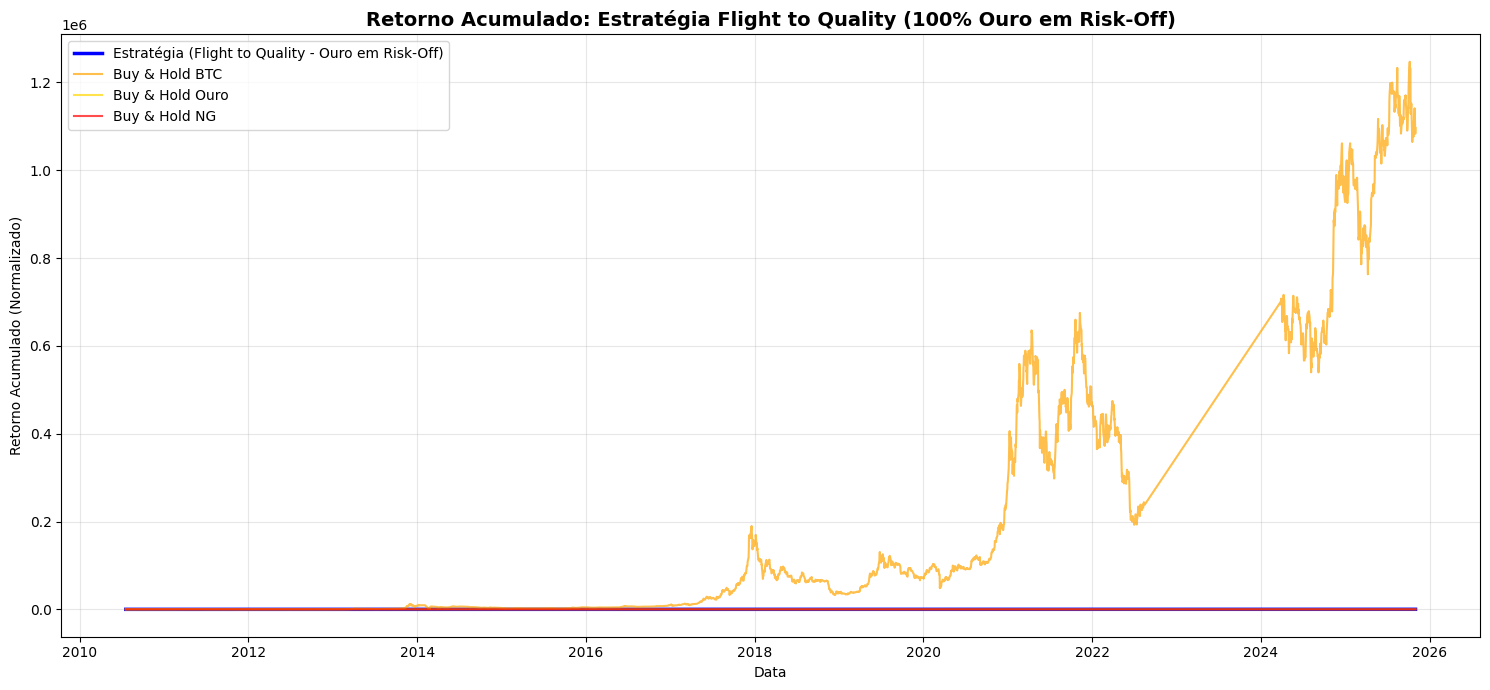


📈 ANÁLISE DETALHADA POR REGIME:
--------------------------------------------------------------------------------

🟢 RISK-ON (VIX < P70):
   Alocação: 50% BTC + 50% Ouro
   Dias: 2415 (70.0%)
   Retorno Acumulado: 10097.75%
   Sharpe Ratio: 1.110
   Taxa de Vitória: 54.20%

🔴 RISK-OFF (VIX > P70):
   Alocação: 100% Ouro (Safe Haven)
   Dias: 1035 (30.0%)
   Retorno Acumulado: -1.90%
   Sharpe Ratio: 0.058
   Taxa de Vitória: 52.08%

💡 PERFORMANCE DOS ATIVOS EM RISK-OFF:
   Ouro:         -1.90%
   BTC:          +194660.61%
   Natural Gas:  +107.40%

✅ Backtest da Estratégia Flight to Quality concluído!


In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Função para carregar os dados
def load_data():
    btc = pd.read_csv('BTC_com_ciclos_HALVING.csv', parse_dates=['Data'], index_col='Data')
    xau = pd.read_csv('XAU-USD.csv', delimiter=';', decimal=',', thousands='.', 
                      parse_dates=['Data'], index_col='Data')
    ng = pd.read_csv('Gas Natural Futures.csv', delimiter=';', decimal=',', thousands='.', 
                     parse_dates=['Data'], index_col='Data')
    macro = pd.read_csv('macro_data.csv', parse_dates=['Date'], index_col='Date')
    return btc, xau, ng, macro


# ========== ESTRATÉGIA: 100% OURO EM RISK-OFF ==========
try:
    btc, xau, ng, macro = load_data()
    
    # Join dos dados de preços
    df_gold = btc.join([xau['Último'].rename('xau'), ng['Último'].rename('ng')], how='inner')
    df_gold = df_gold.join(macro, how='inner')

    # GARANTIR ORDEM CRONOLÓGICA
    df_gold = df_gold.sort_index(ascending=True) 

    # Retornos diários
    df_gold['btc_ret'] = df_gold['btc_price'].pct_change()
    df_gold['xau_ret'] = df_gold['xau'].pct_change()
    df_gold['ng_ret'] = df_gold['ng'].pct_change()

    # --- GATILHO: VIX P70 ---
    vix_p70 = df_gold['vix'].quantile(0.70) 
    df_gold['regime'] = np.where(df_gold['vix'] > vix_p70, 'Risk-Off', 'Risk-On')
    
    print(f"\n📊 ESTRATÉGIA: FLIGHT TO QUALITY - 100% OURO EM RISK-OFF")
    print("="*80)
    print(f"Gatilho VIX P70 = {vix_p70:.2f}")
    print(f"Dias em Risk-On: {(df_gold['regime'] == 'Risk-On').sum()}")
    print(f"Dias em Risk-Off: {(df_gold['regime'] == 'Risk-Off').sum()}")

    # --- ESTRATÉGIA: 100% OURO EM RISK-OFF ---
    # Risk-On: 50% BTC + 50% Ouro
    # Risk-Off: 100% Ouro (safe haven)
    weights = {
        'Risk-On': {'btc_ret': 0.5, 'xau_ret': 0.5, 'ng_ret': 0.0},
        'Risk-Off': {'btc_ret': 0.0, 'xau_ret': 1.0, 'ng_ret': 0.0}  # 100% Ouro
    }

    def strategy_return(row):
        """Calcula o retorno da estratégia baseado no regime"""
        w = weights[row['regime']]
        ret = 0
        for asset_ret, weight in w.items():
            if pd.notna(row[asset_ret]) and weight != 0:
                ret += row[asset_ret] * weight
        return ret

    df_gold['strat_ret'] = df_gold.apply(strategy_return, axis=1)
    
    # Retorno acumulado
    df_gold['strat_cum'] = (1 + df_gold['strat_ret'].fillna(0)).cumprod()

    # --- ANÁLISE DE PERFORMANCE GERAL ---
    print("\n" + "="*80)
    print("PERFORMANCE GERAL DA ESTRATÉGIA")
    print("="*80)
    
    # Retorno total
    retorno_total = (df_gold['strat_cum'].iloc[-1] - 1) * 100
    print(f"\n✅ Retorno Total: {retorno_total:.2f}%")
    
    # Sharpe Ratio
    sharpe = (df_gold['strat_ret'].mean() / df_gold['strat_ret'].std()) * np.sqrt(252)
    print(f"✅ Sharpe Ratio: {sharpe:.3f}")
    
    # Maximum Drawdown
    running_max = np.maximum.accumulate(df_gold['strat_cum'].values)
    drawdown = (df_gold['strat_cum'].values - running_max) / running_max
    max_dd = drawdown.min() * 100
    print(f"✅ Maximum Drawdown: {max_dd:.2f}%")
    
    # Volatilidade
    vol = df_gold['strat_ret'].std() * np.sqrt(252) * 100
    print(f"✅ Volatilidade Anualizada: {vol:.2f}%")
    
    # Taxa de vitória
    win_rate = (df_gold['strat_ret'] > 0).sum() / len(df_gold['strat_ret']) * 100
    print(f"✅ Taxa de Vitória: {win_rate:.2f}%")
    
    print("\n" + "="*80)

    # --- GRÁFICO DE RETORNO ACUMULADO ---
    plt.figure(figsize=(15, 7))
    plt.plot(df_gold.index, df_gold['strat_cum'], 
             label='Estratégia (Flight to Quality - Ouro em Risk-Off)', 
             linewidth=2.5, color='blue')
    
    # Comparação com Buy & Hold
    btc_cum = (1 + df_gold['btc_ret'].fillna(0)).cumprod()
    xau_cum = (1 + df_gold['xau_ret'].fillna(0)).cumprod()
    ng_cum = (1 + df_gold['ng_ret'].fillna(0)).cumprod()
    
    plt.plot(df_gold.index, btc_cum, label='Buy & Hold BTC', 
             linewidth=1.5, color='orange', alpha=0.7)
    plt.plot(df_gold.index, xau_cum, label='Buy & Hold Ouro', 
             linewidth=1.5, color='gold', alpha=0.7)
    plt.plot(df_gold.index, ng_cum, label='Buy & Hold NG', 
             linewidth=1.5, color='red', alpha=0.7)
    
    plt.legend(loc='best')
    plt.title('Retorno Acumulado: Estratégia Flight to Quality (100% Ouro em Risk-Off)', 
              fontsize=14, fontweight='bold')
    plt.xlabel('Data')
    plt.ylabel('Retorno Acumulado (Normalizado)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- ANÁLISE DOS REGIMES ---
    print("\n📈 ANÁLISE DETALHADA POR REGIME:")
    print("-"*80)
    
    # Performance em Risk-On
    risk_on_data = df_gold[df_gold['regime'] == 'Risk-On']
    risk_on_ret = (risk_on_data['strat_ret'].fillna(0) + 1).prod() - 1
    risk_on_sharpe = (risk_on_data['strat_ret'].mean() / risk_on_data['strat_ret'].std()) * np.sqrt(252)
    print(f"\n🟢 RISK-ON (VIX < P70):")
    print(f"   Alocação: 50% BTC + 50% Ouro")
    print(f"   Dias: {len(risk_on_data)} ({len(risk_on_data)/len(df_gold)*100:.1f}%)")
    print(f"   Retorno Acumulado: {risk_on_ret*100:.2f}%")
    print(f"   Sharpe Ratio: {risk_on_sharpe:.3f}")
    print(f"   Taxa de Vitória: {(risk_on_data['strat_ret'] > 0).sum()/len(risk_on_data)*100:.2f}%")
    
    # Performance em Risk-Off
    risk_off_data = df_gold[df_gold['regime'] == 'Risk-Off']
    risk_off_ret = (risk_off_data['strat_ret'].fillna(0) + 1).prod() - 1
    risk_off_sharpe = (risk_off_data['strat_ret'].mean() / risk_off_data['strat_ret'].std()) * np.sqrt(252)
    print(f"\n🔴 RISK-OFF (VIX > P70):")
    print(f"   Alocação: 100% Ouro (Safe Haven)")
    print(f"   Dias: {len(risk_off_data)} ({len(risk_off_data)/len(df_gold)*100:.1f}%)")
    print(f"   Retorno Acumulado: {risk_off_ret*100:.2f}%")
    print(f"   Sharpe Ratio: {risk_off_sharpe:.3f}")
    print(f"   Taxa de Vitória: {(risk_off_data['strat_ret'] > 0).sum()/len(risk_off_data)*100:.2f}%")
    
    # Comparar Ouro vs outros ativos em Risk-Off
    print(f"\n💡 PERFORMANCE DOS ATIVOS EM RISK-OFF:")
    xau_riskoff = (risk_off_data['xau_ret'].fillna(0) + 1).prod() - 1
    btc_riskoff = (risk_off_data['btc_ret'].fillna(0) + 1).prod() - 1
    ng_riskoff = (risk_off_data['ng_ret'].fillna(0) + 1).prod() - 1
    print(f"   Ouro:         {xau_riskoff*100:+.2f}%")
    print(f"   BTC:          {btc_riskoff*100:+.2f}%")
    print(f"   Natural Gas:  {ng_riskoff*100:+.2f}%")
    
    print("\n" + "="*80)
    print("✅ Backtest da Estratégia Flight to Quality concluído!")
    print("="*80)

except FileNotFoundError as e:
    print(f"\n❌ ERRO: Arquivo não encontrado - {e}")
    print("\nVerifique se os arquivos CSV estão no diretório correto")
    
except KeyError as e:
    print(f"\n❌ ERRO: Coluna não encontrada - {e}")
    print("\nVerifique se os nomes das colunas estão corretos")
    
except Exception as e:
    print(f"\n❌ ERRO inesperado: {e}")
    import traceback
    traceback.print_exc()


In [71]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Selecionar o período [2023-2025] ---
anos = [2023, 2024, 2025]
df_gold_sel = df_gold[df_gold.index.year.isin(anos)].copy()

# --- 2. Criar as séries de RETORNO ---
strat_ret = df_gold_sel['strat_ret'].fillna(0)
btc_ret = df_gold_sel['btc_ret'].fillna(0)
xau_ret = df_gold_sel['xau_ret'].fillna(0)
ng_ret = df_gold_sel['ng_ret'].fillna(0)

# --- 3. Calcular retornos acumulados ---
strat_cum = (1 + strat_ret).cumprod()
btc_cum = (1 + btc_ret).cumprod()
xau_cum = (1 + xau_ret).cumprod()
ng_cum = (1 + ng_ret).cumprod()

# --- 4. FUNÇÕES DE MÉTRICAS ---
def sharpe_ratio(returns, periods_per_year=252):
    """Sharpe Ratio anualizado"""
    mean_ret = returns.mean()
    std_ret = returns.std()
    if std_ret == 0 or np.isnan(std_ret):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / std_ret)

def sortino_ratio(returns, periods_per_year=252):
    """Sortino Ratio - considera apenas volatilidade negativa"""
    mean_ret = returns.mean()
    downside_ret = returns[returns < 0]
    downside_std = downside_ret.std()
    if downside_std == 0 or np.isnan(downside_std):
        return 0
    return np.sqrt(periods_per_year) * (mean_ret / downside_std)

def max_drawdown(cum_returns):
    """Maximum Drawdown"""
    running_max = np.maximum.accumulate(cum_returns)
    drawdown = (cum_returns - running_max) / running_max
    return drawdown.min()

def calmar_ratio(returns, cum_returns, periods_per_year=252):
    """Calmar Ratio - retorno anualizado / max drawdown absoluto"""
    total_return = cum_returns.iloc[-1] - 1
    years = len(returns) / periods_per_year
    annualized_return = (1 + total_return) ** (1/years) - 1
    mdd = abs(max_drawdown(cum_returns.values))
    if mdd == 0:
        return 0
    return annualized_return / mdd

def win_rate(returns):
    """Taxa de dias positivos"""
    return (returns > 0).sum() / len(returns) * 100

def volatility(returns, periods_per_year=252):
    """Volatilidade anualizada"""
    return returns.std() * np.sqrt(periods_per_year) * 100

# --- 5. CALCULAR TODAS AS MÉTRICAS ---
estrategias = {
    'Flight to Quality (Ouro Risk-Off)': (strat_ret, strat_cum),
    'Buy & Hold BTC': (btc_ret, btc_cum),
    'Buy & Hold Ouro (XAU)': (xau_ret, xau_cum),
    'Buy & Hold NG': (ng_ret, ng_cum)
}

resultados = []

for nome, (ret, cum) in estrategias.items():
    retorno_total = (cum.iloc[-1] - 1) * 100
    retorno_anualizado = ((1 + retorno_total/100) ** (252/len(ret)) - 1) * 100
    sharpe = sharpe_ratio(ret)
    sortino = sortino_ratio(ret)
    mdd = max_drawdown(cum.values) * 100
    calmar = calmar_ratio(ret, cum)
    vol = volatility(ret)
    taxa_vitoria = win_rate(ret)
    
    resultados.append({
        'Estratégia': nome,
        'Retorno Total (%)': retorno_total,
        'Retorno Anualizado (%)': retorno_anualizado,
        'Volatilidade (%)': vol,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Calmar Ratio': calmar,
        'Max Drawdown (%)': mdd,
        'Taxa de Vitória (%)': taxa_vitoria
    })

# --- 6. CRIAR DATAFRAME COMPARATIVO ---
df_comparacao_gold = pd.DataFrame(resultados)

# --- 7. IMPRIMIR RESULTADOS ---
print("\n" + "=" * 110)
print("COMPARAÇÃO COMPLETA: FLIGHT TO QUALITY (100% OURO EM RISK-OFF) [2023-2025]")
print("=" * 110)
print()

# Formatar melhor a tabela
pd.options.display.float_format = '{:.2f}'.format
print(df_comparacao_gold.to_string(index=False))
print()
print("=" * 110)

# --- 8. ANÁLISE DE RANKING ---
print("\n📊 RANKING POR MÉTRICA:")
print("-" * 110)

metricas_ranking = [
    ('Retorno Total (%)', False),
    ('Sharpe Ratio', False),
    ('Sortino Ratio', False),
    ('Calmar Ratio', False),
    ('Max Drawdown (%)', True),  # True = menor é melhor
    ('Volatilidade (%)', True)
]

for metrica, menor_melhor in metricas_ranking:
    df_sorted = df_comparacao_gold.sort_values(metrica, ascending=menor_melhor)
    print(f"\n🏆 {metrica}:")
    for i, row in enumerate(df_sorted.itertuples(), 1):
        emoji = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
        valor = getattr(row, metrica.replace(' ', '_').replace('(', '').replace(')', '').replace('%', ''))
        print(f"   {emoji} {i}º - {row.Estratégia}: {valor:.2f}")

# --- 9. GRÁFICO DE RETORNOS ACUMULADOS ---
plt.figure(figsize=(16, 8))
plt.plot(strat_cum.index, strat_cum.values, 
         label='Flight to Quality (50% BTC+50% Ouro | 100% Ouro em Risk-Off)', 
         linewidth=2.5, color='blue')
plt.plot(btc_cum.index, btc_cum.values, label='Buy & Hold BTC', 
         linewidth=2, color='orange', alpha=0.8)
plt.plot(xau_cum.index, xau_cum.values, label='Buy & Hold Ouro (XAU)', 
         linewidth=2, color='gold', alpha=0.8)
plt.plot(ng_cum.index, ng_cum.values, label='Buy & Hold Natural Gas (NG)', 
         linewidth=2, color='red', alpha=0.8)

plt.legend(loc='best', fontsize=10)
plt.title('Comparação de Retornos Acumulados - Flight to Quality Strategy [2023-2025]', 
          fontsize=14, fontweight='bold')
plt.xlabel('Data', fontsize=12)
plt.ylabel('Retorno Acumulado (Normalizado)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 10. GRÁFICO DE MÉTRICAS COMPARATIVAS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Comparação de Métricas - Flight to Quality Strategy [2023-2025]', 
             fontsize=16, fontweight='bold')

cores = ['blue', 'orange', 'gold', 'red']

# Sharpe Ratio
ax1 = axes[0, 0]
sharpes = df_comparacao_gold['Sharpe Ratio'].values
ax1.bar(range(4), sharpes, color=cores)
ax1.set_xticks(range(4))
ax1.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax1.set_ylabel('Sharpe Ratio')
ax1.set_title('Sharpe Ratio (Maior = Melhor)')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.grid(True, alpha=0.3)

# Sortino Ratio
ax2 = axes[0, 1]
sortinos = df_comparacao_gold['Sortino Ratio'].values
ax2.bar(range(4), sortinos, color=cores)
ax2.set_xticks(range(4))
ax2.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax2.set_ylabel('Sortino Ratio')
ax2.set_title('Sortino Ratio (Maior = Melhor)')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.grid(True, alpha=0.3)

# Calmar Ratio
ax3 = axes[0, 2]
calmars = df_comparacao_gold['Calmar Ratio'].values
ax3.bar(range(4), calmars, color=cores)
ax3.set_xticks(range(4))
ax3.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax3.set_ylabel('Calmar Ratio')
ax3.set_title('Calmar Ratio (Maior = Melhor)')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.grid(True, alpha=0.3)

# Maximum Drawdown
ax4 = axes[1, 0]
mdds = df_comparacao_gold['Max Drawdown (%)'].values
ax4.bar(range(4), mdds, color=cores)
ax4.set_xticks(range(4))
ax4.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax4.set_ylabel('Max Drawdown (%)')
ax4.set_title('Max Drawdown (Menor = Melhor)')
ax4.grid(True, alpha=0.3)

# Volatilidade
ax5 = axes[1, 1]
vols = df_comparacao_gold['Volatilidade (%)'].values
ax5.bar(range(4), vols, color=cores)
ax5.set_xticks(range(4))
ax5.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax5.set_ylabel('Volatilidade Anualizada (%)')
ax5.set_title('Volatilidade (Menor = Melhor)')
ax5.grid(True, alpha=0.3)

# Retorno Total
ax6 = axes[1, 2]
rets = df_comparacao_gold['Retorno Total (%)'].values
ax6.bar(range(4), rets, color=cores)
ax6.set_xticks(range(4))
ax6.set_xticklabels(['Flight to\nQuality', 'BTC', 'Ouro', 'NG'], rotation=0, ha='center')
ax6.set_ylabel('Retorno Total (%)')
ax6.set_title('Retorno Total (Maior = Melhor)')
ax6.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- 11. ANÁLISE POR REGIME ---
print("\n" + "=" * 110)
print("📈 ANÁLISE DETALHADA POR REGIME [2023-2025]:")
print("=" * 110)

risk_on_data = df_gold_sel[df_gold_sel['regime'] == 'Risk-On']
risk_off_data = df_gold_sel[df_gold_sel['regime'] == 'Risk-Off']

print(f"\n🟢 RISK-ON (VIX < P70):")
print(f"   Dias: {len(risk_on_data)} ({len(risk_on_data)/len(df_gold_sel)*100:.1f}%)")
print(f"   Alocação: 50% BTC + 50% Ouro")
risk_on_cum = (1 + risk_on_data['strat_ret'].fillna(0)).prod()
print(f"   Retorno Acumulado: {(risk_on_cum-1)*100:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ratio(risk_on_data['strat_ret'].fillna(0)):.3f}")
print(f"   Taxa de Vitória: {win_rate(risk_on_data['strat_ret'].fillna(0)):.2f}%")

print(f"\n🔴 RISK-OFF (VIX > P70) - FLIGHT TO QUALITY:")
print(f"   Dias: {len(risk_off_data)} ({len(risk_off_data)/len(df_gold_sel)*100:.1f}%)")
print(f"   Alocação: 100% Ouro (Safe Haven)")
risk_off_cum = (1 + risk_off_data['strat_ret'].fillna(0)).prod()
print(f"   Retorno Acumulado: {(risk_off_cum-1)*100:.2f}%")
print(f"   Sharpe Ratio: {sharpe_ratio(risk_off_data['strat_ret'].fillna(0)):.3f}")
print(f"   Taxa de Vitória: {win_rate(risk_off_data['strat_ret'].fillna(0)):.2f}%")

# Comparar performance dos ativos em Risk-Off
print(f"\n💡 PERFORMANCE DOS ATIVOS EM PERÍODOS DE RISK-OFF:")
xau_riskoff = (risk_off_data['xau_ret'].fillna(0) + 1).prod() - 1
btc_riskoff = (risk_off_data['btc_ret'].fillna(0) + 1).prod() - 1
ng_riskoff = (risk_off_data['ng_ret'].fillna(0) + 1).prod() - 1

print(f"   Ouro (Safe Haven): {xau_riskoff*100:+.2f}%")
print(f"   BTC:                {btc_riskoff*100:+.2f}%")
print(f"   Natural Gas:        {ng_riskoff*100:+.2f}%")

# --- 12. ANÁLISE CONCLUSIVA ---
print("\n" + "=" * 110)
print("💡 ANÁLISE CONCLUSIVA:")
print("=" * 110)

melhor_sharpe = df_comparacao_gold.loc[df_comparacao_gold['Sharpe Ratio'].idxmax(), 'Estratégia']
melhor_retorno = df_comparacao_gold.loc[df_comparacao_gold['Retorno Total (%)'].idxmax(), 'Estratégia']
menor_dd = df_comparacao_gold.loc[df_comparacao_gold['Max Drawdown (%)'].idxmax(), 'Estratégia']
menor_vol = df_comparacao_gold.loc[df_comparacao_gold['Volatilidade (%)'].idxmin(), 'Estratégia']

print(f"\n✅ Melhor Sharpe Ratio (retorno ajustado ao risco): {melhor_sharpe}")
print(f"✅ Maior Retorno Total: {melhor_retorno}")
print(f"✅ Menor Drawdown (mais seguro): {menor_dd}")
print(f"✅ Menor Volatilidade (mais estável): {menor_vol}")

print(f"\n🔍 INSIGHTS DA ESTRATÉGIA FLIGHT TO QUALITY:")
print(f"   • Ouro é considerado safe haven clássico durante períodos de estresse")
print(f"   • Em Risk-On: mantém diversificação entre BTC e Ouro")
print(f"   • Em Risk-Off: move 100% para Ouro buscando proteção de capital")
print(f"   • Esta estratégia prioriza preservação de capital sobre retorno máximo")

print("\n" + "=" * 110)



COMPARAÇÃO COMPLETA: FLIGHT TO QUALITY (100% OURO EM RISK-OFF) [2023-2025]

                       Estratégia  Retorno Total (%)  Retorno Anualizado (%)  Volatilidade (%)  Sharpe Ratio  Sortino Ratio  Calmar Ratio  Max Drawdown (%)  Taxa de Vitória (%)
Flight to Quality (Ouro Risk-Off)             257.96                  120.25             88.28          1.17           6.72          9.44            -12.74                52.58
                   Buy & Hold BTC             359.42                  157.05            158.67          1.00           5.68          5.59            -28.11                51.11
            Buy & Hold Ouro (XAU)             125.41                   65.41             25.01          2.13           4.25          6.69             -9.78                56.76
                    Buy & Hold NG             -55.71                  -39.60            103.30          0.33           0.34         -0.99            -39.97                50.86


📊 RANKING POR MÉTRICA:
-------------

AttributeError: 'Pandas' object has no attribute 'Retorno_Total_'